# EGIT 2024 — K-Means Clustering

Perfiles de gasto y duración del viaje a partir de la Encuesta de Gasto Interno
en Turismo (EGIT) 2024 del DANE, catálogo 864.

El notebook tiene dos partes:

1. **Marco teórico** — qué es k-means, cómo funciona y sus limitaciones.
2. **Aplicación** — consolidación de los cuatro trimestres, limpieza, construcción
   de la matriz de modelado y ejecución de k-means (puntos 0 a 4).

La unidad de análisis es la persona viajera. No se asume seguimiento de la misma
persona entre trimestres. Estructura adaptada de los puntos 0-4 del parcial;
exploración, faltantes e IQR retoman `funciones_notebooks_profesor.txt`.


# Parte 1 — Marco teórico


# K-Means Clustering

### ¿Qué es K-Means?

Algoritmo de aprendizaje no supervisado que busca dividir un conjunto de datos en un numero de grupos, dichos grupos se conocen como CLUSTERS y el número de grupos se identifica con la letra K.

### ¿Por qué aprendizaje no supervisado?

Porque los datos no tienen un "tipo" que indique a qué grupo pertenecen. El algoritmo debe encontrar por sí mismo una estructura en los datos, basado en este caso en similitudes que los acerquen a un centroide.

### ¿Qué es CENTROIDE?

Es el punto central en el que se debe reunir cada uno de los clusters, este se puede mover hasta que se cumpla con una INERCIA/WCSS baja.

### ¿Qué es INERCIA/WCSS?

Para entender esto primero debemos conocer el termino DISTANCIA EUCLIDIANA que es el encargado de medir qué tan lejos se encuentra un punto de otro, en este caso nuestro dato de los centroides para así determinar cual es el centroide más cercano y poder ponerlo en el cluster con menor distancia.

En dos dimensiones, para dos puntos:

Sean dos puntos:

$$
A = (x_1, y_1)
$$

y

$$
B = (x_2, y_2)
$$

La distancia Euclidiana entre ellos se calcula como:

$$
d(A,B) =
\sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}
$$

Cuando los datos tienen varias variables, la distancia se puede expresar como:

$$
d(\mathbf{x},\mathbf{c}) =
\sqrt{
\sum_{j=1}^{p}(x_j-c_j)^2
}
$$

donde:

- $\mathbf{x}$ representa un dato.
- $\mathbf{c}$ representa un centroide.
- $p$ representa el número de características o variables.
- $x_j$ representa el valor del dato en la característica $j$.
- $c_j$ representa el valor del centroide en esa misma característica.

Matemáticamente, un punto se asigna al centroide que produzca la menor distancia:

$$
C(x_i) =
\operatorname*{arg\,min}_{k}
\left\|x_i-\mu_k\right\|^2
$$

Esta expresión simplemente significa:

**"Buscar el centroide más cercano."**

Ahora si, ¿qué es INERCIA o tambien conocido como Within-Cluster Sum of Squares?, pues esta se encarga de medir que tan compacto quedo nuestro cluster después del proceso anterior (DISTANCIA EUCLIDIANA), para que se entienda bien es el que mide qué tan lejos se encuentran los puntos de los centroides, en cada uno de los clusters que se crearon.

Se calcula utilizando la suma de las distancias al cuadrado:

$$
WCSS =
\sum_{k=1}^{K}
\sum_{x_i \in C_k}
\left\|x_i - \mu_k\right\|^2
$$

es decir, **la suma de cuadrados dentro de los clusters.**

Ahora, como se evalua esto:

ya con el resultado lo que se busca es puntos cerca de los centroides, es decir que el resultado sea bajo pero que además esto pase en todos los clusters, razón por la cual en el caso de que en algunos de los puntos se evaluen como lejos de sus centroides (Inercia Alta), los centroides se podran mover hasta que se cumpla que todos son Inercia Baja.

### Volvemos al problema inicial

La **K** 

¿Por qué es un problema? Recordemos que nosotros debemos decirle previamente cuánto vale K, pero todo problema tiene su solución y acá llega el Método del Codo.

### ¿Método del Codo?

Si, basicamnete se ejecuta K-Means utilizando diferentes valores de K y se calcula la inercia correspondiente a cada uno. Después se grafica **K** vs **WCSS** y lo más normal es que a medida que aumenta K baja WCSS, pero llega un punto en el que aumentar K ya no disminuye la inercia de manera importante. Pues ese es el punto que necesitamos, ya cuando los cambios comienzan a ser muy pequeños pues deja de ser util crear ese numero de clusters y por eso cuando encotramos ese punto donde es suficiente para determinar los cambios importantes, ahí esta nuestro K.

# Lógica general

## Fase 1: Selección del hiperparámetro (K) — Método del codo
1. Bucle FOR:
   * Se ejecuta K-Means completo para cada K y se guarda su inercia.
   * Se genera un gráfico con Matplotlib (Eje X: K, Eje Y: Inercia).
* *Criterio de selección:* El valor ideal de K es el punto de inflexión ("codo"), donde agregar más grupos ya no reduce significativamente la inercia.

## Fase 2: Ejecución del algoritmo K-Means

1. Inicialización
   * Selección inicial de las coordenadas de los centroides de forma aleatoria o usando técnicas como K-Means++, reduciendo el riesgo de una mala convergencia.

2. Asignación
   * Cada dato individual se vincula al centroide más próximo a través de la distancia euclidiana.

3. Actualización
   * Recálculo de la posición de cada centroide a través de la media. Debido al movimiento del centroide, cambian sus fronteras y la asignación de los datos.

4. Convergencia
   * El algoritmo llega a su fin cuando los centroides se estabilizan o ningún dato cambia de grupo.

5. Resultado final
   * Dataset etiquetado y coordenadas finales de los centroides.

# Casos de uso ideales

| Caso de uso | Ejemplo |
| --- | --- |
| Segmentación de clientes | Agrupar clientes por hábitos de compra para campañas de marketing |
| Compresión de imágenes | Reducir colores de una imagen agrupando tonos similares |
| Agrupamiento de documentos | Organizar textos por temática sin etiquetas previas |
| Detección de patrones | Agrupar lecturas de sensores IoT con comportamiento similar |

# Limitaciones
1. Definición previa de K
2. Sensibilidad a la escala de variables
3. Sensibilidad a la inicialización
4. Sensibilidad a outliers

# Parte 2 — Aplicación a la EGIT 2024

Fuente: DANE, Encuesta de Gasto Interno en Turismo (EGIT) 2024, catálogo 864. Cuatro trimestres, nueve módulos cada uno.


## Punto 0: Carga de datos
Se leen los 36 CSV extraídos, separados por `|`, sin cargar nuevamente los TXT ni los ZIP. Se conservan códigos como texto y ceros iniciales: tener dígitos no convierte una variable en cuantitativa.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)


In [2]:
# ---------------------------------------------------------------
# 0. Estilo y paleta (colores validados: contraste + daltonismo)
# ---------------------------------------------------------------
COLOR_PRIN = '#2a78d6'   # azul    - slot categórico 1
COLOR_SEC  = '#eb6834'   # naranja - slot categórico 2
COLOR_GRID = '#e1e0d9'
COLOR_AXIS = '#898781'
COLOR_TEXT = '#0b0b0b'
SURFACE    = '#fcfcfb'

plt.rcParams.update({
    'axes.edgecolor': COLOR_AXIS,
    'axes.labelcolor': COLOR_TEXT,
    'xtick.color': COLOR_AXIS,
    'ytick.color': COLOR_AXIS,
    'text.color': COLOR_TEXT,
    'axes.grid': True,
    'grid.color': COLOR_GRID,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
})


def clean_ax(ax):
    """Quita bordes superior/derecho y manda la grilla detrás de los datos."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)


# ---------------------------------------------------------------
# 1. Detección de atípicos por rango intercuartílico
# ---------------------------------------------------------------
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]


# ---------------------------------------------------------------
# 2. Estadísticas descriptivas por grupo
# ---------------------------------------------------------------
def estadisticas_por_grupo(df, variable, grupo, percentiles=(25, 50, 75)):
    """
    Calcula estadísticas descriptivas, de variabilidad, CV y percentiles
    de `variable` agrupando por `grupo`.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    variable : str
        Columna numérica sobre la que se calculan las estadísticas.
    grupo : str
        Columna por la que se agrupa (ej. "Cluster").
    percentiles : tuple
        Percentiles a calcular (en escala 0-100).

    Retorna
    -------
    pd.DataFrame
        Una fila por cada valor de `grupo` con todas las métricas.
    """

    def _stats(s):
        s = s.dropna()
        n = s.count()
        media = s.mean()
        std = s.std(ddof=1)
        var = s.var(ddof=1)
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        mediana = s.median()

        out = {
            "n": n,
            "n_missing": s.isna().sum(),
            "suma": s.sum(),
            "media": media,
            "mediana": mediana,
            "moda": s.mode().iloc[0] if not s.mode().empty else np.nan,
            "min": s.min(),
            "max": s.max(),
            "rango": s.max() - s.min(),
            # Variabilidad
            "var": var,
            "std": std,
            "iqr": iqr,
            "mad": (s - media).abs().mean(),              # desviación media absoluta
            "mad_mediana": (s - mediana).abs().median(),  # MAD robusta
            "error_std_media": std / np.sqrt(n) if n > 0 else np.nan,
            # Coeficientes de variación
            "cv": std / media if media not in (0, np.nan) else np.nan,
            "cv_pct": (std / media) * 100 if media not in (0, np.nan) else np.nan,
            "cv_robusto": iqr / mediana if mediana not in (0, np.nan) else np.nan,
            # Forma
            "skew": s.skew(),
            "kurtosis": s.kurt(),
        }

        for p in percentiles:
            out[f"p{p}"] = s.quantile(p / 100)

        return pd.Series(out)

    resultado = (
        df.groupby(grupo)[variable]
        .apply(_stats)
        .unstack()
    )

    orden_base = [
        "n", "n_missing", "suma", "media", "mediana", "moda",
        "min", "max", "rango", "var", "std", "iqr", "mad", "mad_mediana",
        "error_std_media", "cv", "cv_pct", "cv_robusto", "skew", "kurtosis",
    ]
    orden_pct = [f"p{p}" for p in percentiles]
    resultado = resultado[orden_base + orden_pct]

    return resultado.reset_index()


# Ejemplo de uso:
# stats = estadisticas_por_grupo(df_preparado, variable="gasto_total_viaje", grupo="Cluster")


### 0.2 Carga de los 36 archivos


In [3]:
RAIZ = Path.cwd()
assert (RAIZ / "Bases de datos").is_dir(), "Ejecuta desde K_means."
SALIDA = RAIZ / "Resultados"
SALIDA.mkdir(exist_ok=True)
carpetas = {
    1: "Base de datos-EGIT-Base Anonimizada-I trim2024",
    2: "Base de datos-EGIT-Base Anonimizada-II trim2024",
    3: "III Trim 2024",
    4: "Base de datos-EGIT-Base Anonimizada-IV trim2024",
}
modulos = ["CARACTERISTICAS_GENERALES", "EDUCACION", "FUERZA_DE_TRABAJO",
           "COMPLEMENTARIAS", "TURISMO", "EXCURSIONISMO", "HOGAR",
           "VIVIENDA", "VIVIENDA_USO_RECREATIVO"]
tablas = {}
inventario = []
for trimestre, carpeta in carpetas.items():
    for modulo in modulos:
        ruta = RAIZ / "Bases de datos" / carpeta / (modulo + ".csv")
        tabla = pd.read_csv(ruta, sep="|", dtype="string", encoding="utf-8",
                            keep_default_na=False, na_values=[""])
        assert tabla.columns.is_unique
        tablas[trimestre, modulo] = tabla
        inventario.append({
            "trimestre": trimestre, "modulo": modulo,
            "filas": len(tabla), "columnas": tabla.shape[1],
            "duplicados_exactos": int(tabla.duplicated().sum()),
            "archivo": str(ruta.relative_to(RAIZ)),
        })
inventario = pd.DataFrame(inventario)
assert len(inventario) == 36
display(inventario)

,trimestre,modulo,filas,columnas,duplicados_exactos,archivo
0,1,CARACTERISTICAS_GENERALES,31185,12,0,Bases de datos\Base de datos-EGIT-Base Anonimi...
1,1,EDUCACION,30291,12,0,Bases de datos\Base de datos-EGIT-Base Anonimi...
2,1,FUERZA_DE_TRABAJO,27401,17,0,Bases de datos\Base de datos-EGIT-Base Anonimi...
3,1,COMPLEMENTARIAS,27401,31,0,Bases de datos\Base de datos-EGIT-Base Anonimi...
4,1,TURISMO,27401,92,0,Bases de datos\Base de datos-EGIT-Base Anonimi...
5,1,EXCURSIONISMO,27401,49,0,Bases de datos\Base de datos-EGIT-Base Anonimi...
6,1,HOGAR,10746,23,0,Bases de datos\Base de datos-EGIT-Base Anonimi...
7,1,VIVIENDA,10635,13,0,Bases de datos\Base de datos-EGIT-Base Anonimi...
8,1,VIVIENDA_USO_RECREATIVO,171,13,0,Bases de datos\Base de datos-EGIT-Base Anonimi...
9,2,CARACTERISTICAS_GENERALES,30542,12,0,Bases de datos\Base de datos-EGIT-Base Anonimi...


## Punto 1: Entendimiento y exploración inicial
### 1.1 Dimensiones, tipos, faltantes y esquemas
Son conteos de registros, no estimaciones de población ponderadas por `Fex_c`.

In [4]:
calidad_origen = []
esquemas = []
for (trimestre, modulo), tabla in tablas.items():
    calidad_origen.append(pd.DataFrame({
        "trimestre": trimestre, "modulo": modulo, "variable": tabla.columns,
        "tipo_lectura": tabla.dtypes.astype(str).values,
        "faltantes": tabla.isna().sum().values,
        "porcentaje_faltante": (tabla.isna().mean() * 100).values,
        "valores_distintos": tabla.nunique().values,
    }))
    referencia = tablas[1, modulo].columns
    esquemas.append({
        "trimestre": trimestre, "modulo": modulo,
        "mismo_esquema_que_T1": tabla.columns.equals(referencia),
        "columnas_nuevas": ", ".join(tabla.columns.difference(referencia)),
        "columnas_ausentes": ", ".join(referencia.difference(tabla.columns)),
    })
calidad_origen = pd.concat(calidad_origen, ignore_index=True)
esquemas = pd.DataFrame(esquemas)
display(esquemas)
display(calidad_origen.sort_values("porcentaje_faltante", ascending=False).head(25))

,trimestre,modulo,mismo_esquema_que_T1,columnas_nuevas,columnas_ausentes
0,1,CARACTERISTICAS_GENERALES,True,,
1,1,EDUCACION,True,,
2,1,FUERZA_DE_TRABAJO,True,,
3,1,COMPLEMENTARIAS,True,,
4,1,TURISMO,True,,
5,1,EXCURSIONISMO,True,,
6,1,HOGAR,True,,
7,1,VIVIENDA,True,,
8,1,VIVIENDA_USO_RECREATIVO,True,,
9,2,CARACTERISTICAS_GENERALES,True,,


,trimestre,modulo,variable,tipo_lectura,faltantes,porcentaje_faltante,valores_distintos
736,3,EXCURSIONISMO,P7587S8A3,string,26962,100.000000,0
721,3,EXCURSIONISMO,P7587S4A3,string,26962,100.000000,0
998,4,EXCURSIONISMO,P7587S8A3,string,26017,100.000000,0
474,2,EXCURSIONISMO,P7587S8A3,string,26869,100.000000,0
463,2,EXCURSIONISMO,P7587S5A3,string,26869,100.000000,0
672,3,TURISMO,P7581S5A3,string,26962,100.000000,0
422,2,TURISMO,P7581S8A3,string,26869,100.000000,0
471,2,EXCURSIONISMO,P7587S7A3,string,26869,100.000000,0
459,2,EXCURSIONISMO,P7587S4A3,string,26869,100.000000,0
424,2,TURISMO,P7581S11A2,string,26869,100.000000,0


### 1.2 Alcance de la base

Cada fila representa una persona observada en un trimestre, con información de su hogar y vivienda. Los códigos y categorías se consultan en el [diccionario EGIT 2024](https://microdatos.dane.gov.co/index.php/catalog/864/data-dictionary).


## Punto 2: Calidad de datos y construcción de la base
### 2.0 Estado inicial: granularidad y duplicados
Módulos personales: `Directorio + Secuencia_p + Orden`. Hogar: `llave_hogar`. Vivienda: `Directorio`. Se añade el trimestre a la llave final.

En vivienda recreativa, se conserva cada registro dentro del hogar en columnas separadas. Su `Orden` no se cruza con el orden de una persona. No se suman ni promedian estos registros.

In [5]:
llave_persona = ["Directorio", "Secuencia_p", "Orden"]
llaves = {modulo: llave_persona for modulo in modulos}
llaves["HOGAR"] = ["llave_hogar"]
llaves["VIVIENDA"] = ["Directorio"]
llaves["VIVIENDA_USO_RECREATIVO"] = ["llave_hogar", "Orden"]
control_llaves = []
for (trimestre, modulo), tabla in tablas.items():
    clave = llaves[modulo]
    control_llaves.append({
        "trimestre": trimestre, "modulo": modulo, "llave": " + ".join(clave),
        "filas_sin_llave": int(tabla[clave].isna().any(axis=1).sum()),
        "duplicados_por_llave": int(tabla.duplicated(clave).sum()),
        "duplicados_exactos": int(tabla.duplicated().sum()),
    })
control_llaves = pd.DataFrame(control_llaves)
display(control_llaves)
assert control_llaves["filas_sin_llave"].sum() == 0
assert control_llaves["duplicados_por_llave"].sum() == 0, "Revisar llaves repetidas antes de cruzar."

,trimestre,modulo,llave,filas_sin_llave,duplicados_por_llave,duplicados_exactos
0,1,CARACTERISTICAS_GENERALES,Directorio + Secuencia_p + Orden,0,0,0
1,1,EDUCACION,Directorio + Secuencia_p + Orden,0,0,0
2,1,FUERZA_DE_TRABAJO,Directorio + Secuencia_p + Orden,0,0,0
3,1,COMPLEMENTARIAS,Directorio + Secuencia_p + Orden,0,0,0
4,1,TURISMO,Directorio + Secuencia_p + Orden,0,0,0
5,1,EXCURSIONISMO,Directorio + Secuencia_p + Orden,0,0,0
6,1,HOGAR,llave_hogar,0,0,0
7,1,VIVIENDA,Directorio,0,0,0
8,1,VIVIENDA_USO_RECREATIVO,llave_hogar + Orden,0,0,0
9,2,CARACTERISTICAS_GENERALES,Directorio + Secuencia_p + Orden,0,0,0


### 2.1 Ensamblaje por trimestre
Se conserva a todas las personas de características generales. Los prefijos indican procedencia y evitan sobrescribir columnas. Los indicadores `presente__MODULO` distinguen la ausencia de un registro completo de un vacío dentro del registro; **no certifican que una pregunta no aplique**.

Cada cruce comprueba unicidad, registros sin enlace y conservación de filas. Vivienda recreativa se reorganiza con `set_index().unstack()`, operaciones presentes en el parcial, sin agregación.

In [6]:
bases_trimestrales = []
control_cruces = []
procedencia = []
for trimestre in carpetas:
    base = tablas[trimestre, "CARACTERISTICAS_GENERALES"].copy()
    if trimestre == 1:
        procedencia.extend({
            "columna": c, "modulo": "CARACTERISTICAS_GENERALES", "variable_original": c
        } for c in base.columns)
    for modulo in modulos[1:]:
        fuente = tablas[trimestre, modulo].copy()
        if modulo == "VIVIENDA_USO_RECREATIVO":
            clave = ["llave_hogar"]
            fuente["presente"] = "1"
            derecha = fuente.set_index(["llave_hogar", "Orden"]).unstack("Orden")
            nombres = {
                par: modulo + "__" + par[0] + "__registro_" + str(par[1])
                for par in derecha.columns
            }
            procedencia.extend({
                "columna": nombre, "modulo": modulo, "variable_original": par[0]
            } for par, nombre in nombres.items())
            derecha.columns = [nombres[par] for par in derecha.columns]
            derecha = derecha.reset_index()
        else:
            clave = llaves[modulo]
            nombres = {c: modulo + "__" + c for c in fuente.columns if c not in clave}
            procedencia.extend({
                "columna": nombre, "modulo": modulo, "variable_original": original
            } for original, nombre in nombres.items())
            derecha = fuente.rename(columns=nombres)
        cobertura = derecha[clave].merge(
            base[clave].drop_duplicates(), on=clave, how="left",
            validate="one_to_one", indicator=True
        )
        huerfanas = int((cobertura["_merge"] == "left_only").sum())
        assert huerfanas == 0, f"Registros sin enlace: T{trimestre} {modulo}"
        indicador = "presente__" + modulo
        derecha[indicador] = True
        filas_antes = len(base)
        base = base.merge(derecha, on=clave, how="left", validate="many_to_one")
        base[indicador] = base[indicador].eq(True)
        assert len(base) == filas_antes
        control_cruces.append({
            "trimestre": trimestre, "modulo": modulo,
            "filas_antes": filas_antes, "filas_despues": len(base),
            "personas_sin_registro_modulo": int((~base[indicador]).sum()),
            "registros_huerfanos": huerfanas,
        })
    base["trimestre"] = trimestre
    base["anio"] = 2024
    bases_trimestrales.append(base)
df_consolidado = pd.concat(bases_trimestrales, ignore_index=True)
control_cruces = pd.DataFrame(control_cruces)
procedencia = pd.DataFrame(procedencia).drop_duplicates().reset_index(drop=True)
llave_final = ["trimestre"] + llave_persona
assert not df_consolidado.duplicated(llave_final).any()
assert len(df_consolidado) == inventario.loc[
    inventario["modulo"] == "CARACTERISTICAS_GENERALES", "filas"
].sum()
display(control_cruces)
display(df_consolidado.groupby("trimestre").size().rename("personas").to_frame())
print("Dimensión consolidada:", df_consolidado.shape)

,trimestre,modulo,filas_antes,filas_despues,personas_sin_registro_modulo,registros_huerfanos
0,1,EDUCACION,31185,31185,894,0
1,1,FUERZA_DE_TRABAJO,31185,31185,3784,0
2,1,COMPLEMENTARIAS,31185,31185,3784,0
3,1,TURISMO,31185,31185,3784,0
4,1,EXCURSIONISMO,31185,31185,3784,0
5,1,HOGAR,31185,31185,0,0
6,1,VIVIENDA,31185,31185,0,0
7,1,VIVIENDA_USO_RECREATIVO,31185,31185,30767,0
8,2,EDUCACION,30542,30542,886,0
9,2,FUERZA_DE_TRABAJO,30542,30542,3673,0


,personas
trimestre,
1,31185
2,30542
3,30740
4,29512


Dimensión consolidada: (121979, 278)


### 2.2 Diagnóstico de la base consolidada
Dos personas con las mismas respuestas no son necesariamente duplicados. Los controles conservan identificadores; ninguna alerta elimina columnas o filas automáticamente.

In [7]:
display(pd.DataFrame({
    "control": ["Duplicados exactos", "Duplicados persona-trimestre"],
    "cantidad": [df_consolidado.duplicated().sum(),
                 df_consolidado.duplicated(llave_final).sum()],
}))
calidad_consolidada = pd.DataFrame({
    "tipo": df_consolidado.dtypes.astype(str),
    "faltantes": df_consolidado.isna().sum(),
    "porcentaje_faltante": df_consolidado.isna().mean() * 100,
    "valores_distintos": df_consolidado.nunique(),
})
display(calidad_consolidada.sort_values("porcentaje_faltante", ascending=False).head(30))
display(calidad_consolidada.loc[calidad_consolidada["valores_distintos"] <= 1])

,control,cantidad
0,Duplicados exactos,0
1,Duplicados persona-trimestre,0


,tipo,faltantes,porcentaje_faltante,valores_distintos
EXCURSIONISMO__P7587S8A3,string,121979,100.000000,0
VIVIENDA_USO_RECREATIVO__P38S3A1__registro_3,string,121979,100.000000,0
TURISMO__P7581S11A2,string,121979,100.000000,0
EXCURSIONISMO__P7587S4A3,string,121979,100.000000,0
EXCURSIONISMO__P7587S7A3,string,121978,99.999180,1
EXCURSIONISMO__P7587S2A3,string,121973,99.995081,6
TURISMO__P7581S8A3,string,121972,99.994261,4
TURISMO__P7581S5A3,string,121971,99.993441,5
VIVIENDA_USO_RECREATIVO__P38S2A1__registro_3,string,121970,99.992622,2
EXCURSIONISMO__P7587S5A3,string,121969,99.991802,7


,tipo,faltantes,porcentaje_faltante,valores_distintos
TURISMO__P7581S11A2,string,121979,100.000000,0
EXCURSIONISMO__P7587S4A3,string,121979,100.000000,0
EXCURSIONISMO__P7587S7A3,string,121978,99.999180,1
EXCURSIONISMO__P7587S8A3,string,121979,100.000000,0
HOGAR__Secuencia_p,string,0,0.000000,1
presente__HOGAR,bool,0,0.000000,1
VIVIENDA__Secuencia_p,string,0,0.000000,1
VIVIENDA__Secuencia_encuesta,string,0,0.000000,1
VIVIENDA__Orden,string,0,0.000000,1
presente__VIVIENDA,bool,0,0.000000,1


In [8]:
TECNICAS_REDUNDANTES = [
    c for c in df_consolidado.columns
    if re.search(r"__(Secuencia_encuesta|Fex_c|llave_hogar|Directorio|"
                 r"Secuencia_p|Orden)(__registro_\d+)?$", c)
    or c.startswith("presente__") or "__presente__" in c
]

RENOMBRAR = {
    "Fex_c": "fex_trim",
    "VIVIENDA__area": "ciudad",
    "P6020": "sexo",
    "P6040": "edad",
    "P6050": "parentesco_jefe",
    "EDUCACION__P6170": "asiste_estudio",
    "EDUCACION__P6210": "nivel_educativo",
    "FUERZA_DE_TRABAJO__P6240": "actividad_principal",
    "HOGAR__P36": "hogar_viv_recreativa",
    "HOGAR__P545": "fuente_ingreso_principal",
    "HOGAR__P547": "ingreso_mensual_hogar",
    "TURISMO__P7570": "viajo_pernoctando",
    "TURISMO__P7571S1": "viaje_dentro_pais",
    "TURISMO__P7571S2": "viaje_fuera_pais",
    "TURISMO__P7573S1": "destino_depto",
    "TURISMO__P7573S2": "destino_municipio",
    "TURISMO__P7579": "motivo_no_viajar",
    "TURISMO__P7580": "motivo_viaje",
    "TURISMO__P7580S1": "viaje_con_quien",
    "TURISMO__P549": "fecha_inicio_viaje",
    "TURISMO__P549S1": "fecha_fin_viaje",
    "TURISMO__P15001": "reserva_por_app",
    "TURISMO__P7575": "transporte_principal",
    "TURISMO__P7576": "pago_paquete",
    "TURISMO__P7576S2": "paquete_n_personas",
    "TURISMO__P7576S3": "paquete_monto",
    "TURISMO__P7578": "gasto_total_viaje",
}
# alojamiento: S{n} = tipo usado, S{n}A1 = noches. El S7 usa A2, no A1.
for s in [1, 2, 3, 4, 5, 8, 10]:
    RENOMBRAR[f"TURISMO__P7574S{s}"] = f"aloj{s:02d}_uso"
    RENOMBRAR[f"TURISMO__P7574S{s}A1"] = f"aloj{s:02d}_noches"
RENOMBRAR["TURISMO__P7574S7"] = "aloj07_uso"
RENOMBRAR["TURISMO__P7574S7A2"] = "aloj07_noches"

# rubros: S{n} = ¿gastó?, A1 = monto, A2 = nº personas, A3 = submonto.
# Nombres tomados del boletín técnico EGIT 2024 (gasto per cápita día por rubro)
# y verificados contra el orden de magnitud publicado por el DANE. El S11 no tiene A3.
RUBRO_NOMBRE = {
    1:  "alojamiento",
    3:  "transporte_publico_destino",
    4:  "alimentos_bebidas",
    5:  "otros_gastos",
    6:  "servicios_culturales",
    7:  "souvenirs",
    8:  "bienes_uso_personal",
    9:  "transporte_aereo",
    10: "transporte_terrestre",
    11: "otros_sin_desglose",   # se descarta después: 27 montos en todo 2024
}
RUBRO_CODIGO = {nombre: cod for cod, nombre in RUBRO_NOMBRE.items()}

for cod, nombre in RUBRO_NOMBRE.items():
    RENOMBRAR[f"TURISMO__P7581S{cod}"] = f"gasto_{nombre}_si"
    RENOMBRAR[f"TURISMO__P7581S{cod}A1"] = f"gasto_{nombre}_monto"
    RENOMBRAR[f"TURISMO__P7581S{cod}A2"] = f"gasto_{nombre}_n_personas"
    if cod != 11:
        RENOMBRAR[f"TURISMO__P7581S{cod}A3"] = f"gasto_{nombre}_monto_alt"

assert set(RENOMBRAR) <= set(df_consolidado.columns)
df_consolidado = (df_consolidado
                  .drop(columns=TECNICAS_REDUNDANTES)
                  .rename(columns=RENOMBRAR))
procedencia["columna"] = procedencia["columna"].replace(RENOMBRAR)

print("Técnicas eliminadas:", len(TECNICAS_REDUNDANTES))
print("Renombradas:", len(RENOMBRAR), "| Dimensión:", df_consolidado.shape)

Técnicas eliminadas: 47
Renombradas: 82 | Dimensión: (121979, 231)


In [9]:
def diagnostico(df, columnas, aplica):
    sub = df.loc[aplica, columnas]
    return pd.DataFrame({
        "n_aplica": len(sub),
        "no_nulos": sub.notna().sum(),
        "pct_faltante": (100 * sub.isna().mean()).round(2),
        "n_valores": sub.nunique(dropna=True),
    }).reset_index(names="columna").sort_values("pct_faltante")

es_viajero = df_consolidado["gasto_total_viaje"].notna()
cols_tur = [c for c in df_consolidado.columns
            if c.startswith(("rubro", "aloj"))
            or c in ("gasto_total_viaje", "transporte_principal", "motivo_viaje",
                     "pago_paquete", "fecha_inicio_viaje", "destino_depto")]

print("Viajeros con detalle:", int(es_viajero.sum()))
display(diagnostico(df_consolidado, cols_tur, es_viajero))

Viajeros con detalle: 6762


,columna,n_aplica,no_nulos,pct_faltante,n_valores
0,motivo_viaje,6762,6762,0.00,9
1,destino_depto,6762,6762,0.00,32
2,fecha_inicio_viaje,6762,6762,0.00,383
3,aloj01_uso,6762,6762,0.00,2
5,aloj05_uso,6762,6762,0.00,2
7,aloj02_uso,6762,6762,0.00,2
11,aloj04_uso,6762,6762,0.00,2
9,aloj08_uso,6762,6762,0.00,2
15,aloj03_uso,6762,6762,0.00,2
13,aloj10_uso,6762,6762,0.00,2


### 2.3 Selección, corrección de tipos y eliminación de filas

Se conservan las listas actuales de variables y exclusiones. Las cantidades se convierten a números y los códigos se mantienen como categorías. Se seleccionan registros con gasto total informado.

In [10]:
RUBROS = [n for c, n in RUBRO_NOMBRE.items() if c != 11]   # el 11 se descarta
ALOJ = [1, 2, 3, 4, 5, 7, 8, 10]

columnas_descartar = (
    [c for c in df_consolidado.columns
     if c.startswith(("EXCURSIONISMO__", "COMPLEMENTARIAS__",
                      "VIVIENDA_USO_RECREATIVO__"))]
    + [c for c in df_consolidado.columns if c.endswith("_monto_alt")]
    + [c for c in df_consolidado.columns if c.startswith("gasto_otros_sin_desglose")]
    + ["motivo_no_viajar", "destino_municipio", "TURISMO__P7573S3",
       "TURISMO__P7571S1A1", "TURISMO__P7571S1A2", "TURISMO__P7571S1A3",
       "TURISMO__P7571S2A1", "TURISMO__P7580S3"]
)
columnas_numericas = (
    ["edad", "ingreso_mensual_hogar", "gasto_total_viaje",
     "paquete_monto", "paquete_n_personas", "fex_trim"]
    + [f"gasto_{r}_monto" for r in RUBROS]
    + [f"gasto_{r}_n_personas" for r in RUBROS]
    + [f"aloj{a:02d}_noches" for a in ALOJ]
)
columnas_categoricas = [
    "ciudad", "sexo", "nivel_educativo", "actividad_principal",
    "hogar_viv_recreativa", "fuente_ingreso_principal", "motivo_viaje",
    "viaje_con_quien", "transporte_principal", "pago_paquete",
    "reserva_por_app", "destino_depto",
] + [f"gasto_{r}_si" for r in RUBROS] + [f"aloj{a:02d}_uso" for a in ALOJ]

reemplazos = {}
columnas_exigir_dato = ["gasto_total_viaje"]

assert not set(columnas_descartar) & set(llave_final)
assert not set(columnas_numericas) & set(columnas_categoricas)
assert set(columnas_descartar + columnas_numericas + columnas_categoricas
           + columnas_exigir_dato + list(reemplazos)) <= set(df_consolidado.columns)
df_trabajo = df_consolidado.drop(columns=columnas_descartar).copy()
df_trabajo = df_trabajo.replace(reemplazos)
conversiones = []
for columna in columnas_numericas:
    convertida = pd.to_numeric(df_trabajo[columna], errors="coerce")
    invalidos = df_trabajo[columna].notna() & convertida.isna()
    conversiones.append({"columna": columna, "no_convertibles": int(invalidos.sum())})
    assert not invalidos.any(), f"Revisa los valores no convertibles de {columna}."
    df_trabajo[columna] = convertida.astype(float)
for columna in columnas_categoricas:
    df_trabajo[columna] = df_trabajo[columna].astype("category")
if columnas_exigir_dato:
    df_trabajo = df_trabajo.dropna(subset=columnas_exigir_dato)
display(pd.DataFrame(conversiones, columns=["columna", "no_convertibles"]))
print("Filas retiradas:", len(df_consolidado) - len(df_trabajo))

,columna,no_convertibles
0,edad,0
1,ingreso_mensual_hogar,0
2,gasto_total_viaje,0
3,paquete_monto,0
4,paquete_n_personas,0
5,fex_trim,0
6,gasto_alojamiento_monto,0
7,gasto_transporte_publico_destino_monto,0
8,gasto_alimentos_bebidas_monto,0
9,gasto_otros_gastos_monto,0


Filas retiradas: 115217


### 2.4 Tratamiento de faltantes: imputación con cero

Para este ejercicio se rellenan con **0** los montos faltantes de los nueve rubros, las noches por alojamiento y el monto del paquete. Se conserva la regla actual, sin excluir registros por esos vacíos. La tabla muestra cuántos valores se reemplazan por columna.

**Supuesto y limitación:** se trata un monto desconocido como si fuera cero, incluso cuando no se conoce la respuesta sobre el gasto. Esto puede subestimar montos y modificar las proporciones y los clusters. Es una simplificación del ejercicio, no una comprobación de ausencia de gasto ni de calidad de la imputación.

Un faltante no convierte una variable cuantitativa en cualitativa. Los indicadores Sí/No/No responde no entran como variables al modelo; solo se utilizan las 11 cantidades construidas. El método final es **K-Means**, no KNN.

**Control adicional:** existen montos de gasto total iguales a 98 y 99. La documentación de EGIT 2022 los identifica como códigos de no respuesta, pero la ficha de 2024 consultada no lo aclara. Se mantienen sin recodificar hasta confirmar la convención de 2024; pueden afectar el logaritmo del gasto y los grupos. [EGIT 2022](https://microdatos.dane.gov.co/index.php/catalog/766/variable/F25/V774?name=P7578) · [Ficha 2024](https://microdatos.dane.gov.co/index.php/catalog/864/variable/F17/V567?name=P7578).


In [11]:
todos = pd.Series(True, index=df_trabajo.index)

reglas_imputacion = (
    [{"columna": f"gasto_{r}_monto", "aplica": todos,
      "metodo": "valor", "valor": 0.0} for r in RUBROS]
    + [{"columna": f"aloj{a:02d}_noches", "aplica": todos,
        "metodo": "valor", "valor": 0.0} for a in ALOJ]
    + [{"columna": "paquete_monto", "aplica": todos,
        "metodo": "valor", "valor": 0.0}]
)
registro_imputacion = []
for regla in reglas_imputacion:
    columna = regla["columna"]
    aplica = regla["aplica"]
    assert isinstance(aplica, pd.Series) and aplica.index.equals(df_trabajo.index)
    assert pd.api.types.is_bool_dtype(aplica) and not aplica.isna().any()
    antes = int(df_trabajo.loc[aplica, columna].isna().sum())
    if regla["metodo"] == "media":
        assert columna in columnas_numericas
        valor = df_trabajo.loc[aplica, columna].mean()
    else:
        assert regla["metodo"] == "valor"
        valor = regla["valor"]
    assert pd.notna(valor), "Valor de imputación no válido."
    df_trabajo.loc[aplica, columna] = df_trabajo.loc[aplica, columna].fillna(valor)
    despues = int(df_trabajo.loc[aplica, columna].isna().sum())
    registro_imputacion.append({
        "columna": columna, "metodo": regla["metodo"], "valor": valor,
        "imputados": antes - despues, "faltantes_aplicables": despues,
    })
registro_imputacion = pd.DataFrame(registro_imputacion, columns=[
    "columna", "metodo", "valor", "imputados", "faltantes_aplicables"
])
display(registro_imputacion)

,columna,metodo,valor,imputados,faltantes_aplicables
0,gasto_alojamiento_monto,valor,0.0,5383,0
1,gasto_transporte_publico_destino_monto,valor,0.0,5491,0
2,gasto_alimentos_bebidas_monto,valor,0.0,2621,0
3,gasto_otros_gastos_monto,valor,0.0,5891,0
4,gasto_servicios_culturales_monto,valor,0.0,5949,0
5,gasto_souvenirs_monto,valor,0.0,5754,0
6,gasto_bienes_uso_personal_monto,valor,0.0,6222,0
7,gasto_transporte_aereo_monto,valor,0.0,6030,0
8,gasto_transporte_terrestre_monto,valor,0.0,2987,0
9,aloj01_noches,valor,0.0,6589,0


In [12]:
df_trabajo["duracion_dias"] = (
    pd.to_datetime(df_trabajo["fecha_fin_viaje"], errors="coerce")
    - pd.to_datetime(df_trabajo["fecha_inicio_viaje"], errors="coerce")
).dt.days
df_trabajo["log_gasto_total"] = np.log1p(df_trabajo["gasto_total_viaje"])

COLS_RUBRO = [f"gasto_{r}_monto" for r in RUBROS]
df_trabajo["suma_rubros"] = df_trabajo[COLS_RUBRO].sum(axis=1)
df_trabajo["coherencia"] = df_trabajo["suma_rubros"] / df_trabajo["gasto_total_viaje"]

print("Sin desglose (suma_rubros == 0):", int((df_trabajo["suma_rubros"] == 0).sum()))
display(df_trabajo.loc[df_trabajo["suma_rubros"] > 0, "coherencia"]
        .describe(percentiles=[.05, .25, .5, .75, .95]).round(3))

# los que no tienen desglose no sirven para composición
df_trabajo = df_trabajo.loc[df_trabajo["suma_rubros"] > 0].copy()

for r in RUBROS:
    df_trabajo[f"share_{r}"] = (
        df_trabajo[f"gasto_{r}_monto"] / df_trabajo["suma_rubros"])

# para que el Punto 3 analice las variables que realmente se van a usar
columnas_numericas += (["duracion_dias", "log_gasto_total", "suma_rubros"]
                       + [f"share_{r}" for r in RUBROS])

print("Base para clustering:", df_trabajo.shape)

Sin desglose (suma_rubros == 0): 2033


count    4729.000
mean        0.953
std         0.272
min         0.000
5%          0.378
25%         1.000
50%         1.000
75%         1.000
95%         1.000
max         5.000
Name: coherencia, dtype: float64

Base para clustering: (4729, 135)


### 2.5 Resumen de la preparación

Se conservan registros con gasto total informado, se imputan con cero los campos del apartado 2.4 y se exige suma positiva del desglose utilizado. Se construyen duración, logaritmo del gasto y proporciones por rubro. El Punto 3 excluye atípicos de gasto y duración mediante IQR. Estos criterios definen la muestra del ejercicio; no representan a toda la población de la encuesta.


## Punto 3: Análisis descriptivo y revisión de atípicos

### 3.1 Estadísticos y frecuencias

Se muestran descriptivos de las cantidades y frecuencias de las categorías para la muestra seleccionada, sin ponderación poblacional.

In [13]:
# ---------------------------------------------------------------
# 1. Pool de variables relevantes
#    (las que entran al modelo, más gasto y duración en unidades originales)
# ---------------------------------------------------------------
pool_cols = (
    [f"share_{r}" for r in RUBROS]
    + ["log_gasto_total", "duracion_dias", "gasto_total_viaje", "suma_rubros"]
)
faltantes = [c for c in pool_cols if c not in df_trabajo.columns]
if faltantes:
    print("Columnas no encontradas en df_trabajo (se ignoran):", faltantes)
pool_cols = [c for c in pool_cols if c in df_trabajo.columns]

print(f"Variables en el pool: {len(pool_cols)}")

# ---------------------------------------------------------------
# 2. Estadísticos puntuales
# ---------------------------------------------------------------
desc_stats = df_trabajo[pool_cols].describe().T
desc_stats['skew'] = df_trabajo[pool_cols].skew()
desc_stats['kurtosis'] = df_trabajo[pool_cols].kurt()
desc_stats['missing'] = df_trabajo[pool_cols].isna().sum()
desc_stats = desc_stats.round(2)

print("\n=== Estadísticos puntuales ===")
display(desc_stats)

# ---------------------------------------------------------------
# 3. Frecuencias de las variables categóricas de perfilamiento
# ---------------------------------------------------------------
cat_perfil = ["ciudad", "motivo_viaje", "transporte_principal", "pago_paquete"]
display(pd.concat(
    {c: df_trabajo[c].value_counts(dropna=False) for c in cat_perfil},
    names=["variable", "categoria"]
).rename("frecuencia").to_frame())


Variables en el pool: 13

=== Estadísticos puntuales ===


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,missing
share_alojamiento,4729.0,0.09,0.16,0.0,0.00,0.00,0.19,1.00,1.62,1.84,0
share_transporte_publico_destino,4729.0,0.04,0.09,0.0,0.00,0.00,0.03,1.00,4.92,34.82,0
share_alimentos_bebidas,4729.0,0.36,0.23,0.0,0.20,0.33,0.50,1.00,0.36,-0.16,0
share_otros_gastos,4729.0,0.03,0.09,0.0,0.00,0.00,0.00,1.00,5.80,44.73,0
share_servicios_culturales,4729.0,0.03,0.08,0.0,0.00,0.00,0.00,1.00,4.76,32.64,0
share_souvenirs,4729.0,0.04,0.12,0.0,0.00,0.00,0.00,1.00,4.31,23.57,0
share_bienes_uso_personal,4729.0,0.03,0.10,0.0,0.00,0.00,0.00,1.00,4.77,27.84,0
share_transporte_aereo,4729.0,0.07,0.18,0.0,0.00,0.00,0.00,1.00,2.85,8.03,0
share_transporte_terrestre,4729.0,0.31,0.27,0.0,0.09,0.26,0.45,1.00,0.93,0.34,0
log_gasto_total,4729.0,13.06,1.40,4.6,12.21,13.12,13.91,17.03,-1.76,9.95,0


frecuencia
variable             categoria            
ciudad               15                474
                     17                373
                     68                293
                     11                279
                     52                265
                     05                258
                     66                244
                     19                237
                     73                207
                     18                203
                     44                202
                     76                190
                     23                187
                     20                176
                     50                173
                     88                166
                     41                132
                     70                129
                     27                110
                     08                109
                     63                 98
                     13                 83
                     47                 76
                     54                 65
motivo_viaje         4                2214
                     3                1623
                     6                 302
                     1                 294
                     2                 115
                     5                  84
                     9                  47
                     7                  40
                     8                  10
transporte_principal 3                1848
                     4                1840
                     1                 823
                     5                 197
                     2                  21
pago_paquete         2                4594
                     1                 135

### 3.2 Distribuciones y correlación

Mapa de calor de Pearson para las 11 variables de K-Means, con colores de −1 a 1 y coeficientes a dos decimales, como en el Punto 3.4 del parcial. Se calcula sobre `df_trabajo`, **antes del filtro IQR**. Las proporciones suman 1 y comparten denominador; sus correlaciones deben leerse teniendo en cuenta esa dependencia.


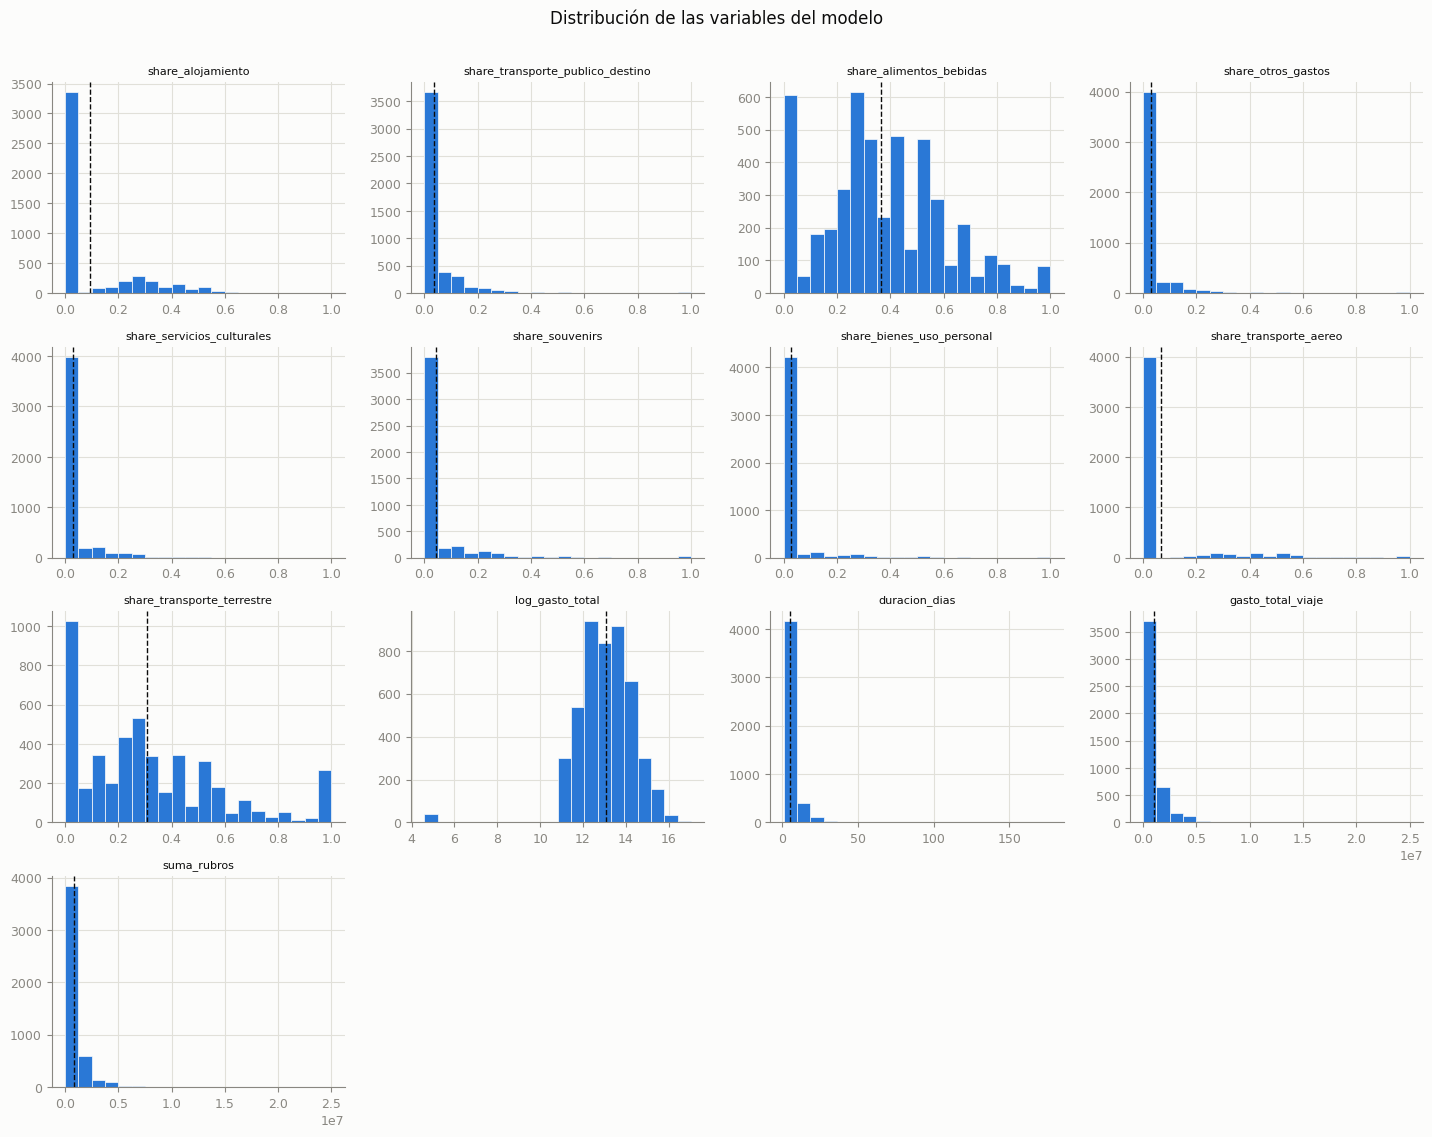

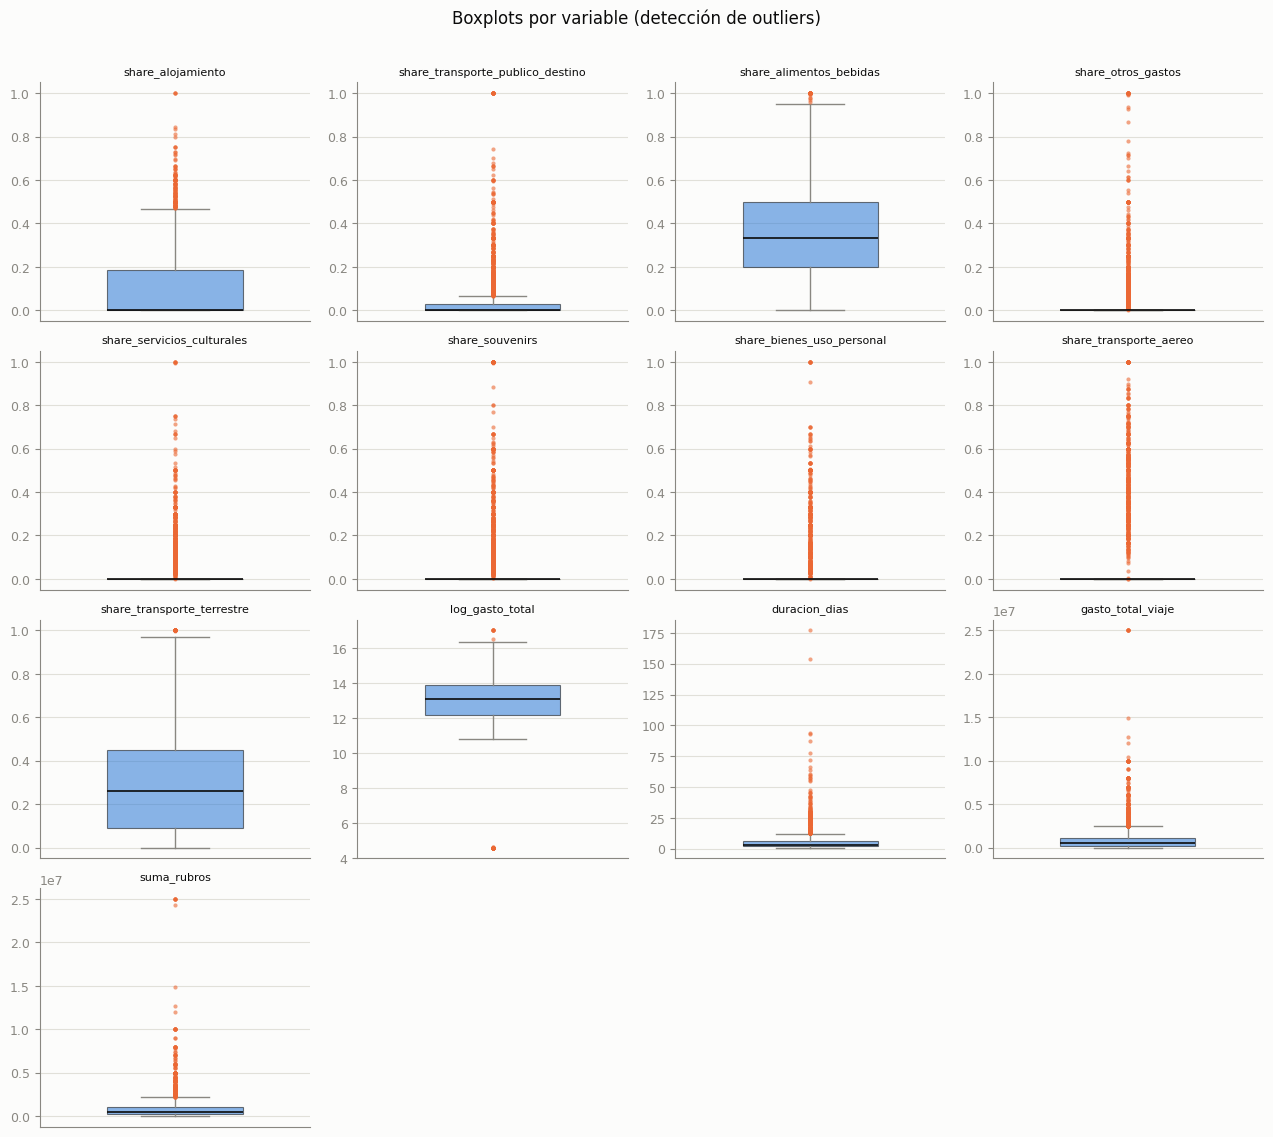

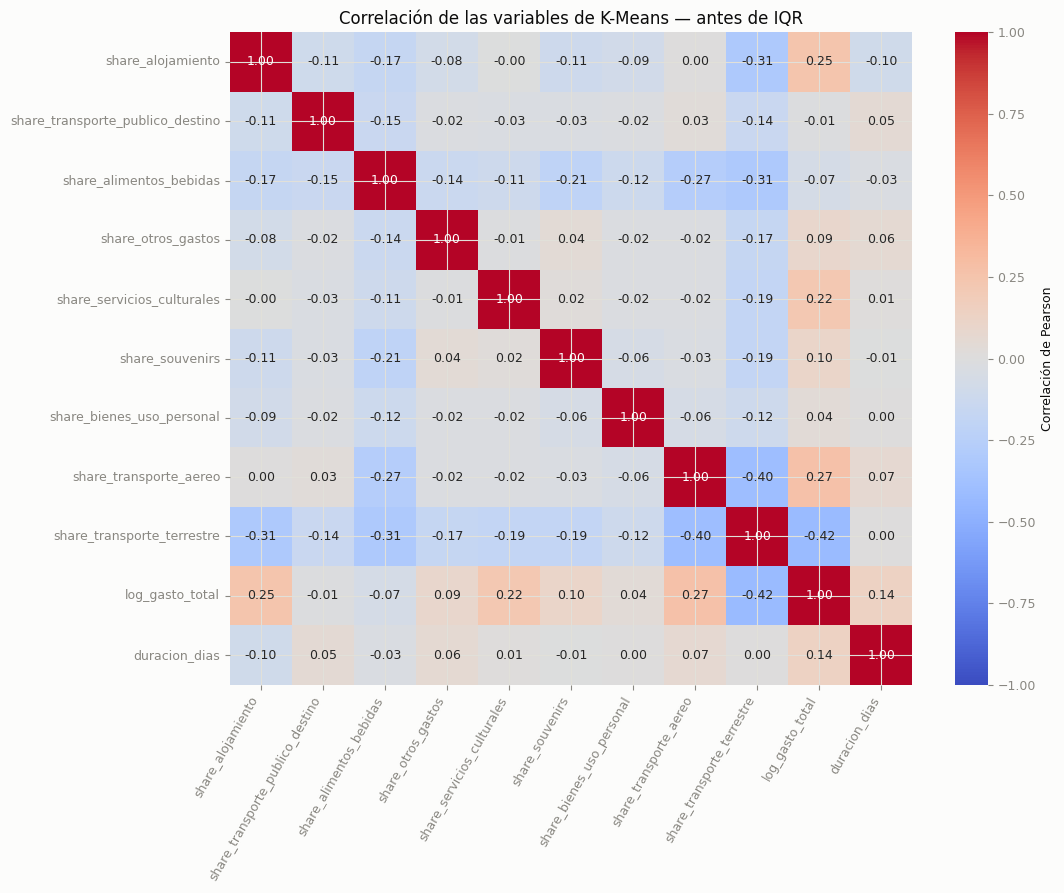

In [14]:
# ---------------------------------------------------------------
# 4. Histogramas (loop: una figura, una grilla de subplots)
# ---------------------------------------------------------------
n_cols = 4
n_vars = len(pool_cols)
n_rows = -(-n_vars // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.6, n_rows * 2.8))
axes = axes.flatten()

for i, col in enumerate(pool_cols):
    ax = axes[i]
    data = df_trabajo[col].dropna()
    ax.hist(data, bins=20, color=COLOR_PRIN, edgecolor=SURFACE, linewidth=0.5)
    ax.axvline(data.mean(), color=COLOR_TEXT, linewidth=1, linestyle='--')
    ax.set_title(col, fontsize=8)
    clean_ax(ax)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Distribución de las variables del modelo', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(SALIDA / 'histogramas_pool.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# 5. Boxplots individuales (loop: detección de outliers por variable)
# ---------------------------------------------------------------
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 2.8))
axes = axes.flatten()

for i, col in enumerate(pool_cols):
    ax = axes[i]
    data = df_trabajo[col].dropna()
    ax.boxplot(
        data, vert=True, patch_artist=True, widths=0.5,
        boxprops=dict(facecolor=COLOR_PRIN, alpha=0.55, edgecolor=COLOR_TEXT, linewidth=0.8),
        medianprops=dict(color=COLOR_TEXT, linewidth=1.2),
        whiskerprops=dict(color=COLOR_AXIS),
        capprops=dict(color=COLOR_AXIS),
        flierprops=dict(markerfacecolor=COLOR_SEC, markeredgecolor='none',
                        markersize=3, alpha=0.6),
    )
    ax.set_title(col, fontsize=8)
    ax.set_xticks([])
    clean_ax(ax)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Boxplots por variable (detección de outliers)', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(SALIDA / 'boxplots_pool.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# 6. Correlación entre las variables del modelo
# ---------------------------------------------------------------
variables_correlacion = (
    [f"share_{r}" for r in RUBROS] + ["log_gasto_total", "duracion_dias"]
)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    df_trabajo[variables_correlacion].corr(), annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
    cbar_kws={"label": "Correlación de Pearson"},
)
ax.set_title('Correlación de las variables de K-Means — antes de IQR', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(SALIDA / 'correlacion_modelo.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Candidatos atípicos mediante IQR

Se presenta el diagnóstico IQR de las cantidades disponibles. La exclusión posterior se limita a `gasto_total_viaje` y `duracion_dias`, las dos variables donde se observaron los extremos de la gráfica.

In [15]:
# ---------------------------------------------------------------
# 7. Conteo de candidatos a atípico por variable
#    (detect_outliers_iqr se definió con las funciones auxiliares)
# ---------------------------------------------------------------
resumen_atipicos = []
for columna in pool_cols:
    candidatos = detect_outliers_iqr(df_trabajo, columna)
    resumen_atipicos.append({
        "variable": columna,
        "observados": int(df_trabajo[columna].notna().sum()),
        "candidatos_iqr": len(candidatos),
        "pct_candidatos": round(100 * len(candidatos) / len(df_trabajo), 2),
    })
resumen_atipicos = pd.DataFrame(resumen_atipicos)
display(resumen_atipicos.sort_values("candidatos_iqr", ascending=False))


,variable,observados,candidatos_iqr,pct_candidatos
5,share_souvenirs,4729,1008,21.32
3,share_otros_gastos,4729,871,18.42
1,share_transporte_publico_destino,4729,859,18.16
4,share_servicios_culturales,4729,813,17.19
7,share_transporte_aereo,4729,732,15.48
6,share_bienes_uso_personal,4729,540,11.42
11,gasto_total_viaje,4729,438,9.26
10,duracion_dias,4729,396,8.37
12,suma_rubros,4729,364,7.70
8,share_transporte_terrestre,4729,264,5.58


### 3.4 Exclusión de atípicos de gasto y duración

Se utiliza la regla existente: límites **Q1 − 1,5 × IQR** y **Q3 + 1,5 × IQR**. Se retira una fila si queda fuera en gasto total o duración. Los límites se calculan una sola vez sobre la muestra previa; no se repite el recorte hasta eliminar todos los extremos.

Un valor extremo no demuestra un error de captura: esta exclusión delimita la muestra del ejercicio y deja fuera viajes de gasto o duración elevados. Los registros excluidos se conservan en `atipicos_excluidos`; los CSV originales permanecen intactos.

In [16]:
variables_iqr = ["gasto_total_viaje", "duracion_dias"]
limites_iqr = []
marcas_iqr = pd.DataFrame(index=df_trabajo.index)

for columna in variables_iqr:
    q1 = df_trabajo[columna].quantile(0.25)
    q3 = df_trabajo[columna].quantile(0.75)
    iqr = q3 - q1
    candidatos = detect_outliers_iqr(df_trabajo, columna)
    marcas_iqr[columna] = df_trabajo.index.isin(candidatos.index)
    limites_iqr.append({
        "Variable": columna,
        "Límite inferior": q1 - 1.5 * iqr,
        "Límite superior": q3 + 1.5 * iqr,
        "Filas marcadas": len(candidatos),
    })

excluir_iqr = marcas_iqr.any(axis=1)
indices_excluir = df_trabajo.index[excluir_iqr]
atipicos_excluidos = df_trabajo.loc[indices_excluir].copy()
df_preparado = df_trabajo.drop(index=indices_excluir).copy()
assert not df_preparado.duplicated(llave_final).any()

display(pd.DataFrame(limites_iqr))
display(pd.DataFrame({
    "Etapa": ["Antes de IQR", "Excluidas por IQR", "Después de IQR"],
    "Observaciones": [len(df_trabajo), len(atipicos_excluidos), len(df_preparado)],
}))
print("Porcentaje excluido:", round(100 * excluir_iqr.mean(), 2), "%")
display(pd.DataFrame({
    "Máximo antes": df_trabajo[variables_iqr].max(),
    "Máximo después": df_preparado[variables_iqr].max(),
}))

,Variable,Límite inferior,Límite superior,Filas marcadas
0,gasto_total_viaje,-1150000.0,2450000.0,438
1,duracion_dias,-4.0,12.0,396


,Etapa,Observaciones
0,Antes de IQR,4729
1,Excluidas por IQR,778
2,Después de IQR,3951


Porcentaje excluido: 16.45 %


,Máximo antes,Máximo después
gasto_total_viaje,25000000.0,2450000.0
duracion_dias,177.0,12.0


## Punto 4: Preparación, K-Means y comparación de clusters

### 4.1 Las 11 variables que recibe K-Means

- **Nueve proporciones:** `share_rubro01`, `share_rubro03`, `share_rubro04`, `share_rubro05`, `share_rubro06`, `share_rubro07`, `share_rubro08`, `share_rubro09` y `share_rubro10`.
- **Gasto:** `log_gasto_total = log(1 + gasto_total_viaje)`.
- **Duración:** `duracion_dias = fecha_fin_viaje − fecha_inicio_viaje`.

Cada proporción es el monto de su rubro dividido por `suma_rubros`: 0,25 representa el 25 % de la suma de los nueve rubros utilizados, **no necesariamente el 25 % del gasto total declarado**. Las proporciones suman 1 y tienen una dependencia entre sí.

El gasto bruto, edad, ingreso, noches por alojamiento, ciudad y sexo no se añaden como dimensiones del modelo. La tabla siguiente detalla el origen y la fórmula de cada entrada.

In [17]:
variables_modelado = (
    [f"share_{r}" for r in RUBROS]
    + ["log_gasto_total", "duracion_dias"]
)
X_previo = df_preparado.loc[:, variables_modelado].copy()
detalle_variables = pd.DataFrame({
    "Variable de entrada": variables_modelado,
    "Origen / fórmula": [
        f"TURISMO.P7581S{RUBRO_CODIGO[r]}A1 / suma_rubros" for r in RUBROS
    ] + ["log(1 + TURISMO.P7578)", "fecha_fin_viaje - fecha_inicio_viaje"],
    "Unidad antes de escalar": ["Proporción entre 0 y 1"] * len(RUBROS)
        + ["Logaritmo del gasto en pesos más 1", "Días"],
})
display(detalle_variables)
display(pd.DataFrame({
    "tipo": X_previo.dtypes.astype(str),
    "faltantes": X_previo.isna().sum(),
    "valores_distintos": X_previo.nunique(),
}))
print("Variables seleccionadas:", len(variables_modelado))
assert not X_previo.isna().any().any(), "La matriz contiene faltantes."
assert np.isfinite(X_previo.to_numpy(dtype=float)).all(), "La matriz contiene valores no finitos."
print("Observaciones:", len(X_previo))
print("Estado: matriz sin faltantes ni valores no finitos, lista para K-Means.")

,Variable de entrada,Origen / fórmula,Unidad antes de escalar
0,share_alojamiento,TURISMO.P7581S1A1 / suma_rubros,Proporción entre 0 y 1
1,share_transporte_publico_destino,TURISMO.P7581S3A1 / suma_rubros,Proporción entre 0 y 1
2,share_alimentos_bebidas,TURISMO.P7581S4A1 / suma_rubros,Proporción entre 0 y 1
3,share_otros_gastos,TURISMO.P7581S5A1 / suma_rubros,Proporción entre 0 y 1
4,share_servicios_culturales,TURISMO.P7581S6A1 / suma_rubros,Proporción entre 0 y 1
5,share_souvenirs,TURISMO.P7581S7A1 / suma_rubros,Proporción entre 0 y 1
6,share_bienes_uso_personal,TURISMO.P7581S8A1 / suma_rubros,Proporción entre 0 y 1
7,share_transporte_aereo,TURISMO.P7581S9A1 / suma_rubros,Proporción entre 0 y 1
8,share_transporte_terrestre,TURISMO.P7581S10A1 / suma_rubros,Proporción entre 0 y 1
9,log_gasto_total,log(1 + TURISMO.P7578),Logaritmo del gasto en pesos más 1


,tipo,faltantes,valores_distintos
share_alojamiento,float64,0,314
share_transporte_publico_destino,float64,0,266
share_alimentos_bebidas,float64,0,540
share_otros_gastos,float64,0,191
share_servicios_culturales,float64,0,179
share_souvenirs,float64,0,222
share_bienes_uso_personal,float64,0,141
share_transporte_aereo,float64,0,172
share_transporte_terrestre,float64,0,535
log_gasto_total,float64,0,296


Variables seleccionadas: 11
Observaciones: 3951
Estado: matriz sin faltantes ni valores no finitos, lista para K-Means.


### 4.1.1 Visualización antes de K-Means, después del filtro IQR

Se representan dos proporciones continuas del gasto: rubros 04 y 10. Son dos entradas del modelo; no un resumen de sus once dimensiones. Se usa el mismo par antes y después de agrupar.

La duración tiene valores enteros y produce franjas verticales cuando se usa como eje. Cambiar de ejes evita esas franjas, pero no garantiza nubes separadas: los datos simulados fueron generados con grupos, mientras que aquí se explora una encuesta real. No se alteran observaciones para obtener una forma determinada.


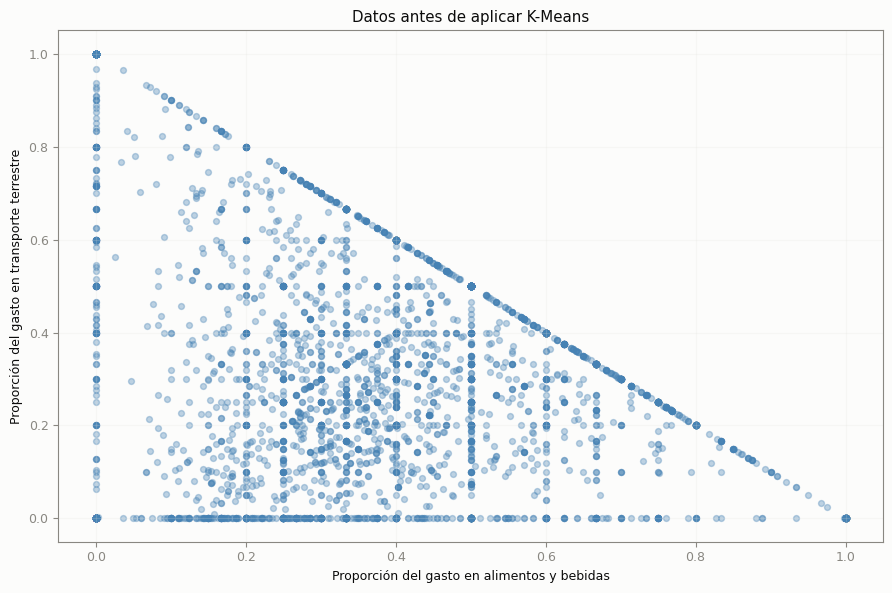

In [18]:
variables_visualizacion = ["share_alimentos_bebidas", "share_transporte_terrestre"]
plt.figure(figsize=(9, 6))
plt.scatter(
    X_previo[variables_visualizacion[0]],
    X_previo[variables_visualizacion[1]],
    color="steelblue", s=18, alpha=0.35
)
plt.title("Datos antes de aplicar K-Means")
plt.xlabel("Proporción del gasto en alimentos y bebidas")
plt.ylabel("Proporción del gasto en transporte terrestre")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### 4.1.2 Escalamiento, sin reducción de dimensionalidad

`StandardScaler` resta la media y divide por la desviación estándar de cada variable. Cambia las unidades, pero conserva las 11 columnas. La transformación logarítmica del gasto tampoco reduce el número de variables. [Referencia](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

In [19]:
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X_previo)

print("Antes de escalar:", X_previo.shape)
print("Después de escalar:", X_escalado.shape)
assert X_escalado.shape == X_previo.shape

pd.DataFrame(
    X_escalado, columns=variables_modelado, index=X_previo.index
).head()

Antes de escalar: (3951, 11)
Después de escalar: (3951, 11)


,share_alojamiento,share_transporte_publico_destino,share_alimentos_bebidas,share_otros_gastos,share_servicios_culturales,share_souvenirs,share_bienes_uso_personal,share_transporte_aereo,share_transporte_terrestre,log_gasto_total,duracion_dias
19,-0.556151,-0.381878,0.114486,4.053965,-0.309030,-0.347283,-0.282262,-0.332913,-0.473388,0.242417,0.256820
26,0.814906,0.524006,-1.237075,-0.281683,0.589885,-0.347283,0.814228,-0.332913,0.400648,1.471070,-0.151344
27,1.020564,0.486260,-1.252718,-0.281683,0.552430,-0.347283,0.768541,-0.332913,0.333207,1.471070,-0.151344
30,1.289760,-0.381878,-0.664768,-0.281683,-0.309030,2.143844,-0.282262,-0.332913,-0.536947,0.629898,-0.151344
74,-0.556151,-0.381878,0.977983,-0.281683,-0.309030,-0.347283,-0.282262,2.077309,-1.217937,0.242417,-0.151344


### 4.1.3 Método del codo: K de 1 a 50

Se conserva el rango ampliado. Se busca un cambio de pendiente: a partir de cierto K, los grupos adicionales reducen menos la inercia.

**Elección manual: K=9**, tomando como referencia la reducción relativa al pasar de 8 a 9 grupos. Un porcentaje mayor no demuestra por sí solo que K sea óptimo: también se compara con las mejoras vecinas y con la forma de la curva. No se selecciona K automáticamente.

La tabla muestra el porcentaje calculado en cada ejecución, no un valor fijo. Se utiliza la imputación con cero documentada en el Punto 2; K=9 permanece como elección manual.


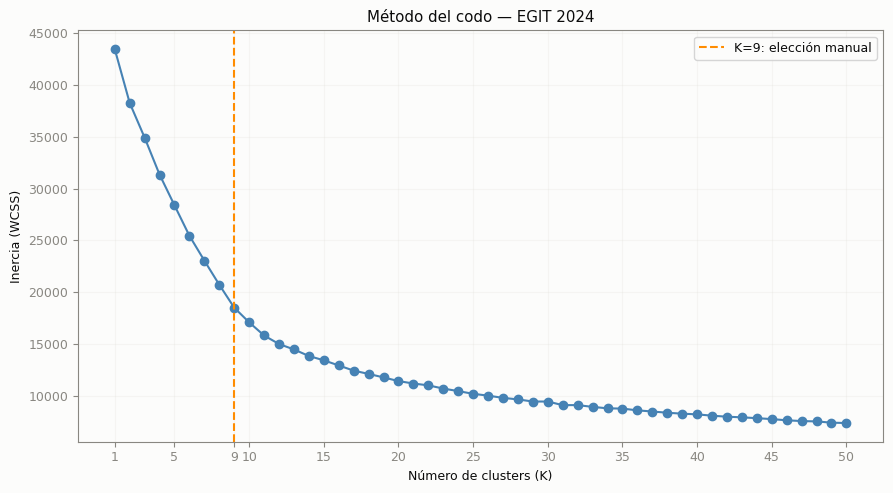

,K,Inercia (WCSS),Reducción de inercia respecto a K anterior (%)
0,1,43461.00,NaN
1,2,38269.81,11.94
2,3,34922.67,8.75
3,4,31358.68,10.21
4,5,28390.89,9.46
5,6,25453.06,10.35
6,7,23059.37,9.40
7,8,20729.72,10.10
8,9,18518.78,10.67
9,10,17101.99,7.65


In [20]:
k_elegido = 9  # Elección manual; no calculada por otro algoritmo.
valores_k = range(1, 51)
inercias = []

for numero_clusters in valores_k:
    modelo = KMeans(
        n_clusters=numero_clusters,
        random_state=42,
        n_init=10
    )
    modelo.fit(X_escalado)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(valores_k, inercias, marker="o", color="steelblue")
plt.xticks([1, 5, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50])
plt.axvline(k_elegido, color="darkorange", linestyle="--", label="K=9: elección manual")
plt.legend()
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (WCSS)")
plt.title("Método del codo — EGIT 2024")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

tabla_codo = pd.DataFrame({"K": list(valores_k), "Inercia (WCSS)": inercias})
tabla_codo["Reducción de inercia respecto a K anterior (%)"] = (
    -tabla_codo["Inercia (WCSS)"].pct_change() * 100
)
display(tabla_codo.round(2))

### 4.1.4 Entrenamiento de K-Means con nueve grupos

Se entrena el modelo con las 11 variables estandarizadas y **K=9**, elegido manualmente. `fit_predict()` ajusta los centroides y asigna cada observación al grupo más cercano. Se suma 1 a las etiquetas para presentar los clusters del 1 al 9; los números identifican grupos, no un orden de importancia.


In [21]:
kmeans = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_escalado)
df_preparado["Cluster"] = pd.Series(clusters + 1, index=X_previo.index)

assert df_preparado["Cluster"].notna().all()
assert df_preparado["Cluster"].nunique() == k_elegido
print("Observaciones agrupadas:", len(df_preparado))
print("Número de clusters:", df_preparado["Cluster"].nunique())


Observaciones agrupadas: 3951
Número de clusters: 9


### 4.1.5 Tamaño de los clusters

Se muestra cuántos registros contiene cada grupo y qué porcentaje representa sobre la muestra modelada.


In [22]:
observaciones_cluster = df_preparado["Cluster"].value_counts().sort_index()
porcentaje_cluster = (
    df_preparado["Cluster"].value_counts(normalize=True).sort_index() * 100
)
tamano_clusters = pd.DataFrame({
    "Observaciones": observaciones_cluster,
    "Porcentaje (%)": porcentaje_cluster.round(2)
})
tamano_clusters.index.name = "Cluster"
display(tamano_clusters)


,Observaciones,Porcentaje (%)
Cluster,,
1,241,6.10
2,682,17.26
3,126,3.19
4,381,9.64
5,1300,32.90
6,203,5.14
7,183,4.63
8,752,19.03
9,83,2.10


### 4.1.6 Información del modelo y centroides

La inercia (WCSS) mide la suma de distancias cuadradas a los centroides en el espacio escalado. Se muestran las iteraciones realizadas y los centroides estandarizados.


In [23]:
print("Inercia (WCSS):", round(kmeans.inertia_, 2))
print("Iteraciones realizadas:", kmeans.n_iter_)
centroides_escalados = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=variables_modelado,
    index=pd.Index(range(1, k_elegido + 1), name="Cluster")
)
display(centroides_escalados.round(2))


Inercia (WCSS): 18518.78
Iteraciones realizadas: 23


,share_alojamiento,share_transporte_publico_destino,share_alimentos_bebidas,share_otros_gastos,share_servicios_culturales,share_souvenirs,share_bienes_uso_personal,share_transporte_aereo,share_transporte_terrestre,log_gasto_total,duracion_dias
Cluster,,,,,,,,,,,
1,-0.20,-0.14,-0.18,-0.04,3.15,-0.01,-0.10,-0.20,-0.41,0.50,0.10
2,-0.46,-0.12,-0.88,-0.22,-0.29,-0.28,-0.26,-0.31,1.64,-0.93,-0.10
3,-0.47,4.14,-0.18,-0.15,-0.21,-0.08,-0.25,-0.29,-0.62,-0.21,0.23
4,0.04,0.14,-0.66,-0.04,-0.13,-0.02,-0.14,2.79,-1.12,0.85,0.40
5,-0.53,-0.18,0.99,-0.11,-0.24,-0.19,-0.21,-0.33,-0.00,-0.12,0.01
6,-0.42,-0.06,-0.34,-0.06,-0.21,-0.24,3.74,-0.30,-0.39,0.08,0.04
7,-0.49,-0.20,-0.64,0.03,-0.16,3.55,-0.24,-0.32,-0.38,0.08,0.05
8,1.74,-0.21,-0.17,-0.14,-0.09,-0.19,-0.18,-0.27,-0.42,0.44,-0.27
9,-0.49,-0.16,-0.66,5.34,-0.29,0.10,-0.28,-0.23,-0.63,0.13,0.46


Al deshacer el escalamiento, los centroides vuelven a las unidades de entrada: proporciones, días y logaritmo del gasto. **El gasto sigue en logaritmo**, no en pesos; el gasto promedio en pesos se consulta en la tabla de promedios.


In [24]:
centroides_originales = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=variables_modelado,
    index=pd.Index(range(1, k_elegido + 1), name="Cluster")
)
display(centroides_originales.round(2))


,share_alojamiento,share_transporte_publico_destino,share_alimentos_bebidas,share_otros_gastos,share_servicios_culturales,share_souvenirs,share_bienes_uso_personal,share_transporte_aereo,share_transporte_terrestre,log_gasto_total,duracion_dias
Cluster,,,,,,,,,,,
1,0.06,0.02,0.33,0.02,0.27,0.04,0.02,0.02,0.22,13.46,3.61
2,0.02,0.03,0.17,0.01,0.00,0.01,0.00,0.00,0.77,11.63,3.13
3,0.01,0.43,0.33,0.01,0.01,0.03,0.00,0.01,0.16,12.55,3.94
4,0.09,0.05,0.22,0.02,0.01,0.04,0.01,0.52,0.03,13.90,4.35
5,0.00,0.02,0.60,0.02,0.01,0.02,0.01,0.00,0.33,12.65,3.39
6,0.02,0.03,0.30,0.02,0.01,0.01,0.38,0.00,0.22,12.92,3.47
7,0.01,0.02,0.22,0.03,0.01,0.48,0.00,0.00,0.23,12.91,3.49
8,0.36,0.02,0.33,0.01,0.02,0.02,0.01,0.01,0.22,13.38,2.71
9,0.01,0.02,0.22,0.52,0.00,0.05,0.00,0.02,0.16,12.98,4.51


### 4.1.7 Visualización de clusters y centroides

La primera gráfica muestra las mismas dos proporciones del apartado 4.1.1, ahora estandarizadas y coloreadas por grupo. Las X son las dos coordenadas correspondientes de los centroides. **La superposición en dos ejes no permite juzgar por sí sola la separación en once dimensiones.** No se aplica PCA ni se modifica la muestra para separar visualmente los puntos.

El mapa de perfiles muestra los nueve centroides en las **once variables estandarizadas**: rojo indica valores por encima de la media de la muestra y azul, por debajo. Permite ver diferencias que no aparecen en el scatter; no es una matriz de correlación ni una prueba de calidad del agrupamiento.


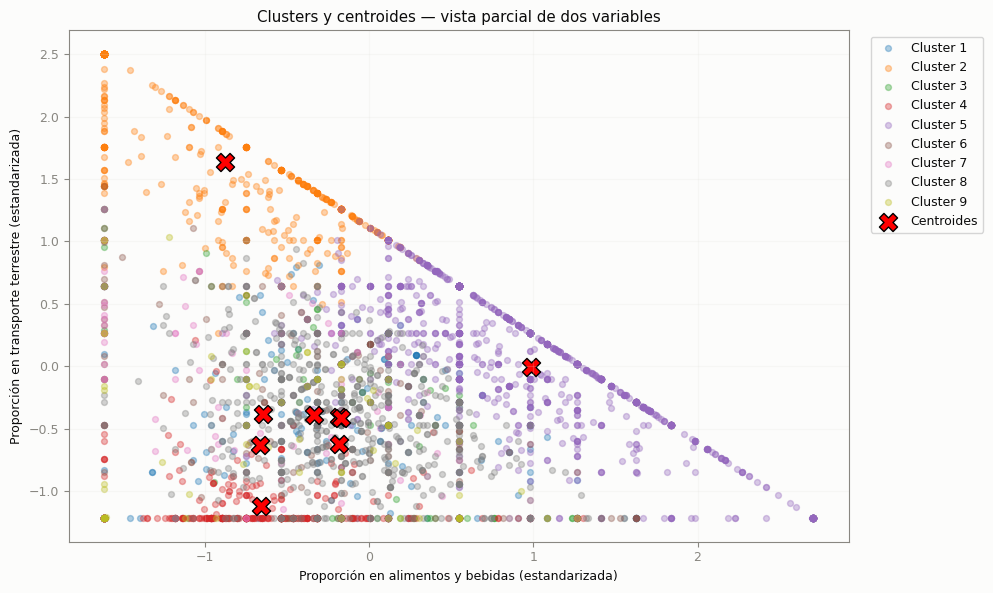

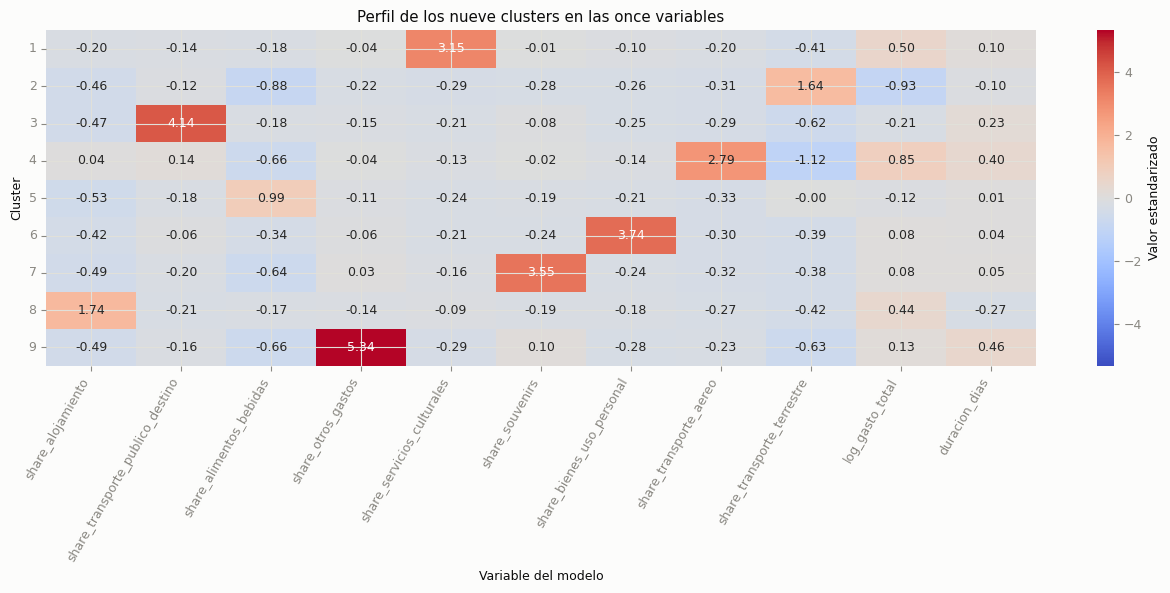

In [25]:
# Vista parcial: mismas dos variables del gráfico inicial, estandarizadas.
pos_x = variables_modelado.index(variables_visualizacion[0])
pos_y = variables_modelado.index(variables_visualizacion[1])
plt.figure(figsize=(10, 6))
colores = plt.get_cmap("tab10")
for numero_cluster in range(1, k_elegido + 1):
    mascara = clusters == numero_cluster - 1
    plt.scatter(
        X_escalado[mascara, pos_x], X_escalado[mascara, pos_y],
        color=colores(numero_cluster - 1), s=18, alpha=0.35,
        label=f"Cluster {numero_cluster}"
    )
plt.scatter(
    kmeans.cluster_centers_[:, pos_x], kmeans.cluster_centers_[:, pos_y],
    marker="X", s=170, color="red", edgecolors="black", label="Centroides"
)
plt.title("Clusters y centroides — vista parcial de dos variables")
plt.xlabel("Proporción en alimentos y bebidas (estandarizada)")
plt.ylabel("Proporción en transporte terrestre (estandarizada)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Perfil completo: se muestran las once coordenadas de cada centroide.
plt.figure(figsize=(13, 6))
limite_color = float(centroides_escalados.abs().max().max())
sns.heatmap(
    centroides_escalados, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-limite_color, vmax=limite_color,
    cbar_kws={"label": "Valor estandarizado"}
)
plt.title("Perfil de los nueve clusters en las once variables")
plt.xlabel("Variable del modelo")
plt.ylabel("Cluster")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.1.8 Biplot de ACP

El analisis de componentes principales proyecta las once variables sobre dos ejes
para poder ver la nube completa en un plano. Los puntos son los viajeros y las
flechas son las variables originales: cada una apunta hacia donde crece, su
longitud indica que tan bien la representa el plano y el angulo entre dos flechas
aproxima su correlacion.

El ACP se usa aqui **solo para visualizar**. Los clusters se calcularon en las once
dimensiones, no sobre estos dos componentes. Dos grupos pueden verse superpuestos
en la proyeccion y estar separados en el espacio real.


=== Varianza explicada por componente ===


,Componente,Varianza explicada (%),Varianza acumulada (%)
0,PC1,17.2,17.2
1,PC2,12.5,29.8
2,PC3,10.9,40.7
3,PC4,10.1,50.8
4,PC5,9.5,60.3
5,PC6,9.2,69.5
6,PC7,9.1,78.6
7,PC8,8.4,87.0
8,PC9,7.5,94.5
9,PC10,5.5,100.0


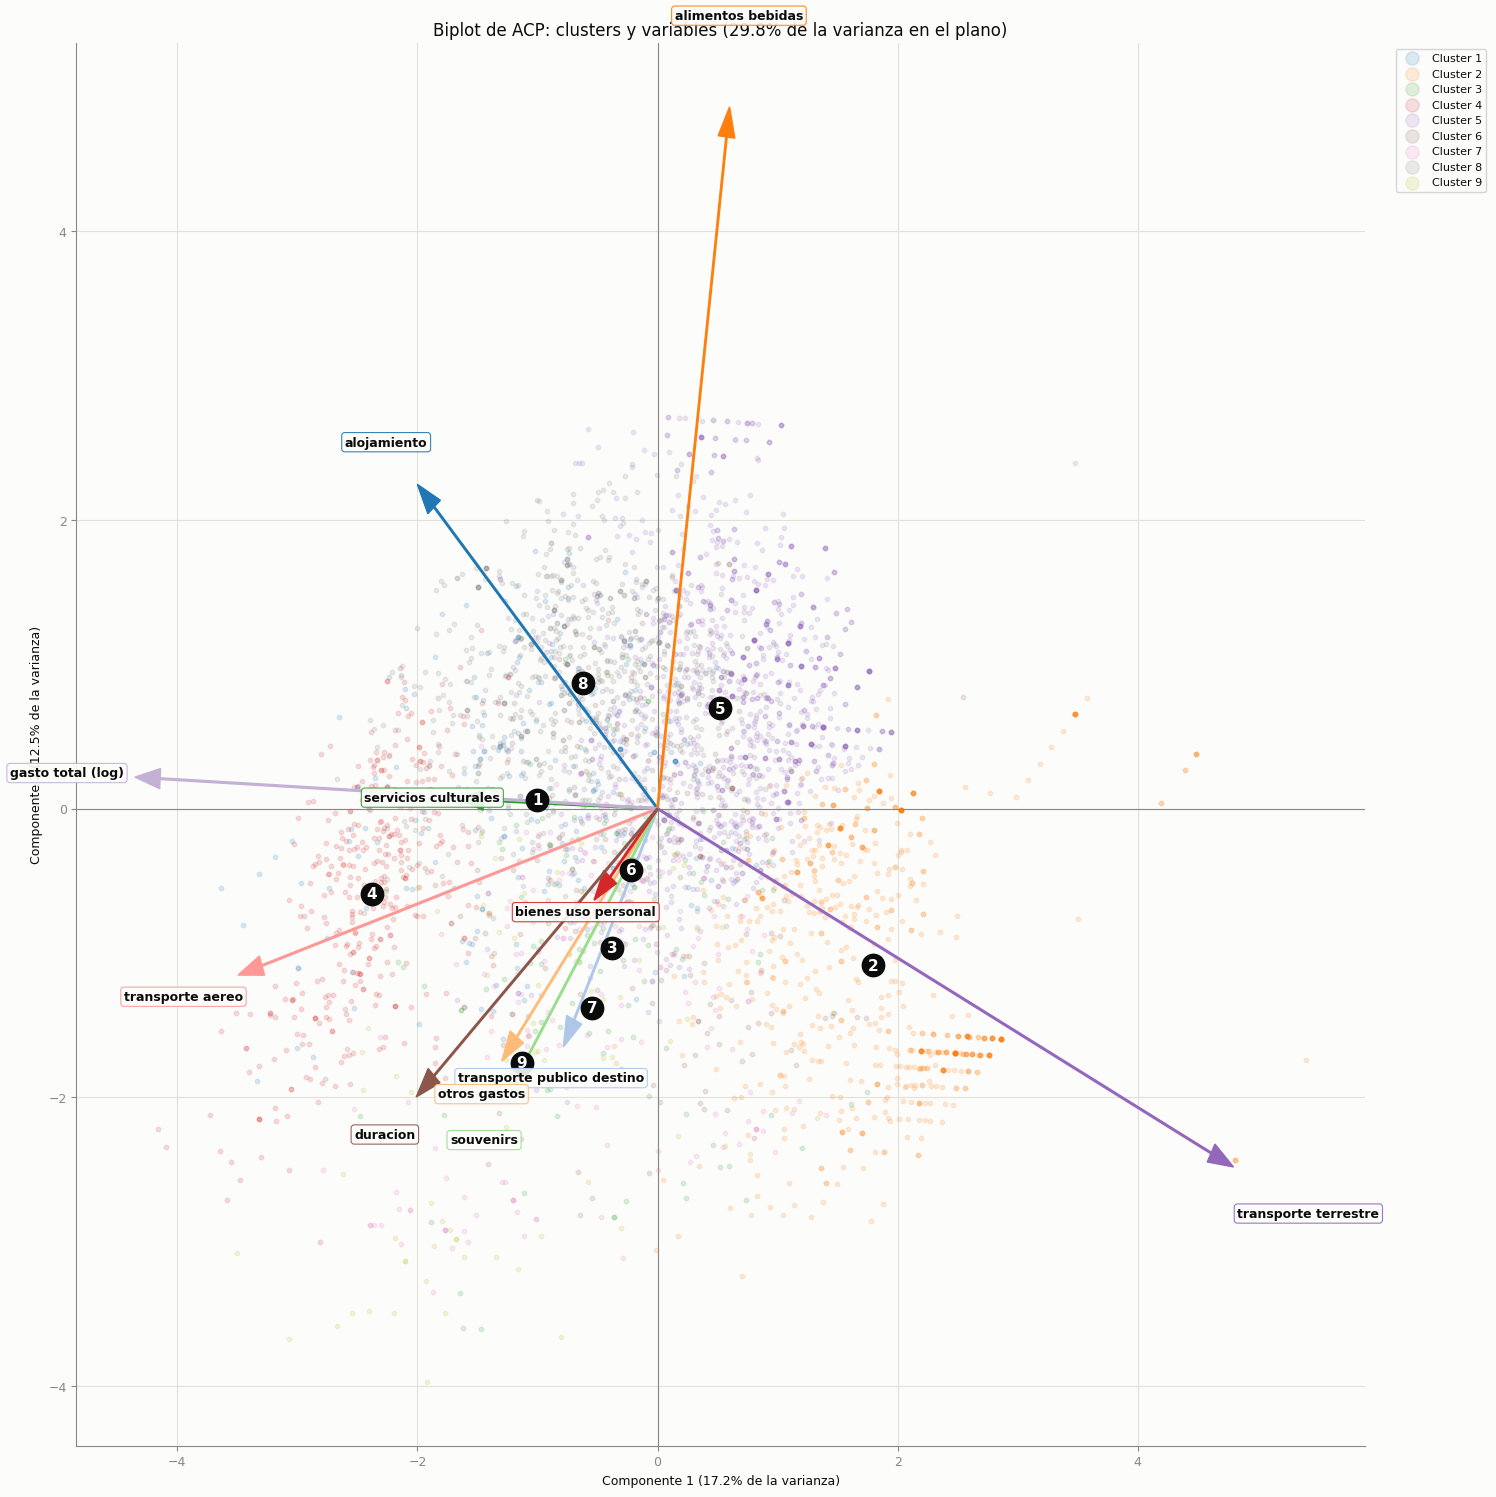


=== Cargas sobre los dos primeros componentes ===


,PC1,PC2,|PC1|+|PC2|
share_transporte_terrestre,0.79,-0.41,1.20
share_alimentos_bebidas,0.10,0.80,0.90
share_transporte_aereo,-0.58,-0.19,0.77
log_gasto_total,-0.72,0.04,0.76
share_alojamiento,-0.33,0.37,0.70
duracion_dias,-0.33,-0.33,0.66
share_souvenirs,-0.21,-0.34,0.55
share_otros_gastos,-0.21,-0.29,0.50
share_transporte_publico_destino,-0.13,-0.27,0.40
share_servicios_culturales,-0.27,0.01,0.28


In [34]:
paleta_vars = plt.get_cmap("tab20")

# ---------------------------------------------------------------
# 1. Ajuste del ACP sobre la matriz ya escalada
# ---------------------------------------------------------------
acp = PCA(random_state=42)
coords = acp.fit_transform(X_escalado)
var_exp = acp.explained_variance_ratio_ * 100

varianza = pd.DataFrame({
    "Componente": [f"PC{i}" for i in range(1, len(var_exp) + 1)],
    "Varianza explicada (%)": var_exp.round(1),
    "Varianza acumulada (%)": var_exp.cumsum().round(1),
})
print("=== Varianza explicada por componente ===")
display(varianza)

# ---------------------------------------------------------------
# 2. Cargas escaladas: coordenadas de las flechas del biplot
# ---------------------------------------------------------------
cargas = acp.components_.T * np.sqrt(acp.explained_variance_)

ETIQUETAS = {f"share_{r}": r.replace("_", " ") for r in RUBROS}
ETIQUETAS["log_gasto_total"] = "gasto total (log)"
ETIQUETAS["duracion_dias"] = "duracion"

# ---------------------------------------------------------------
# 3. Biplot: nube de puntos por cluster + flechas de las variables
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 15))
colores = plt.get_cmap("tab10")

for numero_cluster in range(1, k_elegido + 1):
    mascara = clusters == numero_cluster - 1
    ax.scatter(coords[mascara, 0], coords[mascara, 1],
               color=colores(numero_cluster - 1), s=10, alpha=0.15,
               label=f"Cluster {numero_cluster}")

centroides_acp = acp.transform(kmeans.cluster_centers_)[:, :2]
ax.scatter(centroides_acp[:, 0], centroides_acp[:, 1],
           marker="o", s=260, color=COLOR_TEXT, zorder=5)
for i, (x, y) in enumerate(centroides_acp, start=1):
    ax.annotate(str(i), (x, y), fontsize=11, fontweight="bold",
                color=SURFACE, ha="center", va="center", zorder=6)

escala = 0.9 * np.abs(coords[:, :2]).max() / np.abs(cargas[:, :2]).max()
for j, variable in enumerate(variables_modelado):
    c = paleta_vars(j)
    ax.arrow(0, 0, cargas[j, 0] * escala, cargas[j, 1] * escala,
             color=c, width=0.012, head_width=0.14,
             length_includes_head=True, zorder=4)
    ax.text(cargas[j, 0] * escala * 1.13, cargas[j, 1] * escala * 1.13,
            ETIQUETAS[variable], color=COLOR_TEXT, fontsize=9,
            fontweight="bold", ha="center", va="center", zorder=7,
            bbox=dict(boxstyle="round,pad=0.25", facecolor=SURFACE,
                      edgecolor=c, linewidth=0.8, alpha=0.9))

ax.axhline(0, color=COLOR_AXIS, lw=0.8)
ax.axvline(0, color=COLOR_AXIS, lw=0.8)
ax.set_xlabel(f"Componente 1 ({var_exp[0]:.1f}% de la varianza)")
ax.set_ylabel(f"Componente 2 ({var_exp[1]:.1f}% de la varianza)")
ax.set_title(f"Biplot de ACP: clusters y variables "
             f"({var_exp[:2].sum():.1f}% de la varianza en el plano)", fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=3, fontsize=8)
clean_ax(ax)
plt.tight_layout()
plt.savefig(SALIDA / 'biplot_acp.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# 4. Contribucion de cada variable a los dos primeros componentes
# ---------------------------------------------------------------
tabla_cargas = pd.DataFrame(
    cargas[:, :2], index=variables_modelado, columns=["PC1", "PC2"]
).round(2)
tabla_cargas["|PC1|+|PC2|"] = tabla_cargas.abs().sum(axis=1)
print("\n=== Cargas sobre los dos primeros componentes ===")
display(tabla_cargas.sort_values("|PC1|+|PC2|", ascending=False))


### 4.1.9 Perfilamiento de los clusters



=== gasto_total_viaje por cluster ===


,Cluster,n,n_missing,suma,media,mediana,moda,min,max,rango,var,std,iqr,mad,mad_mediana,error_std_media,cv,cv_pct,cv_robusto,skew,kurtosis,p25,p50,p75
0,1,241.0,0.0,215612000.0,894655.60,700000.0,500000.0,50000.0,2400000.0,2350000.0,3.510060e+11,592457.62,860000.0,495597.56,330000.0,38163.55,0.66,66.22,1.23,0.73,-0.63,400000.0,700000.0,1260000.0
1,2,682.0,0.0,160143628.0,234814.70,150000.0,100000.0,98.0,2300000.0,2299902.0,7.841305e+10,280023.30,220000.0,175252.68,90000.0,10722.65,1.19,119.25,1.47,3.55,17.64,80000.0,150000.0,300000.0
2,3,126.0,0.0,49831000.0,395484.13,300000.0,200000.0,50000.0,2000000.0,1950000.0,1.243944e+11,352695.94,350000.0,250957.80,150000.0,31420.65,0.89,89.18,1.17,2.00,4.77,150000.0,300000.0,500000.0
3,4,381.0,0.0,469271000.0,1231682.41,1200000.0,1000000.0,80000.0,2400000.0,2320000.0,2.887530e+11,537357.39,800000.0,452372.90,400000.0,27529.65,0.44,43.63,0.67,0.18,-0.90,800000.0,1200000.0,1600000.0
4,5,1300.0,0.0,579226598.0,445558.92,300000.0,200000.0,98.0,2300000.0,2299902.0,1.647523e+11,405896.92,300000.0,287457.62,170000.0,11257.56,0.91,91.10,1.00,2.02,4.50,200000.0,300000.0,500000.0
5,6,203.0,0.0,120972098.0,595921.67,400000.0,400000.0,98.0,2000000.0,1999902.0,2.476351e+11,497629.51,555000.0,382403.48,200000.0,34926.74,0.84,83.51,1.39,1.36,1.16,245000.0,400000.0,800000.0
6,7,183.0,0.0,110045750.0,601342.90,400000.0,300000.0,50000.0,2300000.0,2250000.0,3.055381e+11,552754.97,610000.0,424977.96,200000.0,40860.82,0.92,91.92,1.52,1.48,1.41,200000.0,400000.0,810000.0
7,8,752.0,0.0,634896600.0,844277.39,700000.0,1000000.0,50000.0,2400000.0,2350000.0,3.394154e+11,582593.68,808500.0,481547.89,370000.0,21245.01,0.69,69.01,1.16,0.81,-0.37,391500.0,700000.0,1200000.0
8,9,83.0,0.0,54547000.0,657192.77,500000.0,500000.0,50000.0,2450000.0,2400000.0,3.366136e+11,580184.11,670000.0,444491.80,300000.0,63683.48,0.88,88.28,1.34,1.39,1.29,235000.0,500000.0,905000.0



=== duracion_dias por cluster ===


,Cluster,n,n_missing,suma,media,mediana,moda,min,max,rango,var,std,iqr,mad,mad_mediana,error_std_media,cv,cv_pct,cv_robusto,skew,kurtosis,p25,p50,p75
0,1,241.0,0.0,871.0,3.61,3.0,3.0,1.0,12.0,11.0,5.80,2.41,3.0,1.88,1.0,0.16,0.67,66.66,1.00,1.13,0.75,2.0,3.0,5.0
1,2,682.0,0.0,2138.0,3.13,2.0,1.0,1.0,12.0,11.0,6.36,2.52,3.0,1.92,1.0,0.10,0.80,80.43,1.50,1.51,1.69,1.0,2.0,4.0
2,3,126.0,0.0,497.0,3.94,3.0,3.0,1.0,12.0,11.0,7.86,2.80,4.0,2.27,1.5,0.25,0.71,71.08,1.33,1.01,0.03,2.0,3.0,6.0
3,4,381.0,0.0,1657.0,4.35,4.0,3.0,1.0,12.0,11.0,6.64,2.58,3.0,2.02,2.0,0.13,0.59,59.24,0.75,1.13,0.60,3.0,4.0,6.0
4,5,1300.0,0.0,4402.0,3.39,3.0,2.0,1.0,12.0,11.0,6.01,2.45,2.0,1.89,1.0,0.07,0.72,72.41,0.67,1.40,1.61,2.0,3.0,4.0
5,6,203.0,0.0,704.0,3.47,3.0,2.0,1.0,11.0,10.0,5.32,2.31,3.0,1.85,1.0,0.16,0.67,66.51,1.00,1.13,0.97,2.0,3.0,5.0
6,7,183.0,0.0,639.0,3.49,3.0,2.0,1.0,12.0,11.0,6.34,2.52,2.0,1.87,1.0,0.19,0.72,72.11,0.67,1.51,2.02,2.0,3.0,4.0
7,8,752.0,0.0,2036.0,2.71,2.0,1.0,1.0,12.0,11.0,3.80,1.95,2.0,1.41,1.0,0.07,0.72,72.02,1.00,1.88,4.20,1.0,2.0,3.0
8,9,83.0,0.0,374.0,4.51,4.0,3.0,1.0,12.0,11.0,8.45,2.91,5.0,2.45,2.0,0.32,0.65,64.50,1.25,0.69,-0.33,2.0,4.0,7.0



=== Proporciones promedio por rubro (%) ===


,share_alojamiento,share_transporte_publico_destino,share_alimentos_bebidas,share_otros_gastos,share_servicios_culturales,share_souvenirs,share_bienes_uso_personal,share_transporte_aereo,share_transporte_terrestre
Cluster,,,,,,,,,
1,5.69,2.32,33.16,2.27,26.73,4.08,1.77,2.22,21.76
2,1.51,2.51,17.07,0.60,0.13,0.78,0.25,0.37,76.77
3,1.31,43.40,33.13,1.21,0.77,3.28,0.28,0.64,15.99
4,9.48,5.04,22.10,2.25,1.37,3.95,1.37,51.82,2.62
5,0.41,1.89,60.21,1.60,0.51,1.92,0.68,0.09,32.68
6,2.23,3.10,29.58,2.03,0.75,1.32,38.29,0.47,22.22
7,1.00,1.77,22.41,2.85,1.12,47.75,0.40,0.16,22.53
8,36.47,1.64,33.41,1.29,1.68,1.87,0.98,1.10,21.56
9,0.98,2.11,21.97,51.88,0.12,5.46,0.00,1.69,15.78


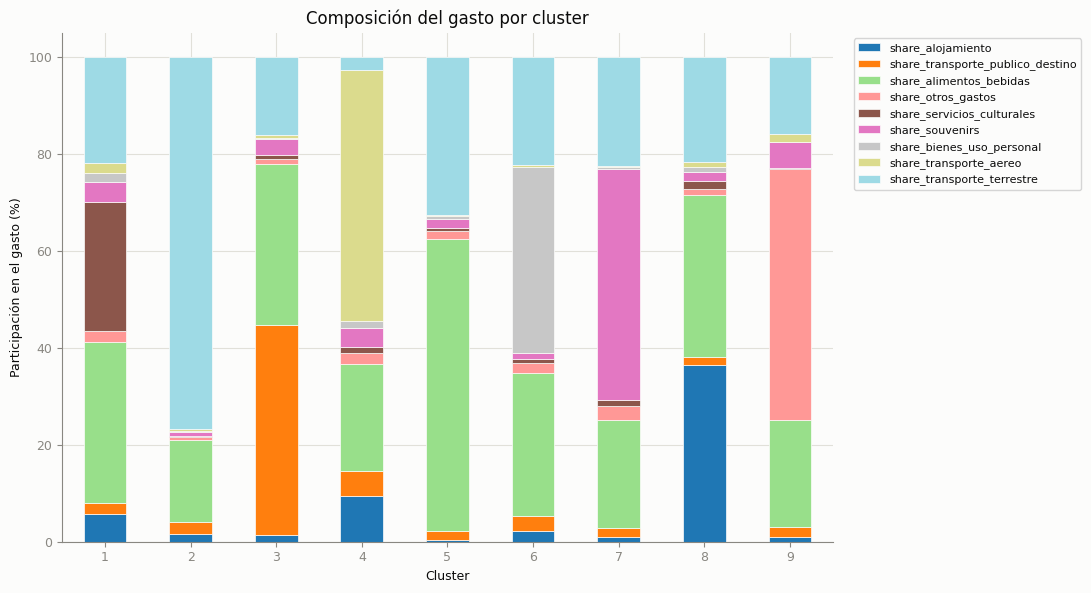

In [27]:
# ---------------------------------------------------------------
# 1. Estadísticas completas por cluster (gasto y duración)
# ---------------------------------------------------------------
for variable in ["gasto_total_viaje", "duracion_dias"]:
    print(f"\n=== {variable} por cluster ===")
    display(
        estadisticas_por_grupo(df_preparado, variable=variable, grupo="Cluster")
        .round(2)
    )

# ---------------------------------------------------------------
# 2. Composición del gasto por cluster (%)
# ---------------------------------------------------------------
proporciones_clusters = df_preparado.groupby("Cluster")[
    [f"share_{r}" for r in RUBROS]
].mean() * 100
print("\n=== Proporciones promedio por rubro (%) ===")
display(proporciones_clusters.round(2))

# ---------------------------------------------------------------
# 3. Composición del gasto por cluster (gráfico de barras apiladas)
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))
proporciones_clusters.plot(
    kind="bar", stacked=True, ax=ax, colormap="tab20", edgecolor=SURFACE, linewidth=0.5
)
ax.set_ylabel("Participación en el gasto (%)")
ax.set_xlabel("Cluster")
ax.set_title("Composición del gasto por cluster", fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=0)
clean_ax(ax)
plt.tight_layout()
plt.savefig(SALIDA / 'composicion_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
